# 04 — Time Series

Time series analysis deals with observations collected sequentially over time.

Unlike ordinary machine learning datasets, time series data has an important property:

> **The order of observations matters.**

Examples include:

- Stock prices
- Temperature measurements
- Electricity demand
- Sales and revenue
- Website traffic
- Sensor measurements
- Economic indicators
- Weather observations
- Production data

The main goals of time series analysis are:

1. Understand temporal patterns
2. Detect trend and seasonality
3. Measure dependence between observations
4. Determine whether a series is stationary
5. Build statistical models
6. Forecast future observations
7. Evaluate forecasts correctly


## 1. What Is a Time Series?

A time series is a sequence of observations indexed by time.

We can represent a univariate time series as:

$$
\{y_1, y_2, y_3, \ldots, y_T\}
$$

where:

- $y_t$ is the observation at time $t$
- $t$ represents the time index
- $T$ is the total number of observations

For example:

| Date | Sales |
|---|---:|
| Jan 1 | 120 |
| Jan 2 | 135 |
| Jan 3 | 128 |
| Jan 4 | 150 |
| Jan 5 | 161 |

The observations are not treated as independent and identically distributed samples.

Instead, an observation at time $t$ may depend on previous observations:

$$
y_t = f(y_{t-1}, y_{t-2}, \ldots) + \epsilon_t
$$

This temporal dependence is the foundation of time series modeling.

## 2. Time Series vs Ordinary Machine Learning Data

In ordinary supervised learning, we often assume that observations can be shuffled without changing the meaning of the dataset.

For example:

$$
(X_i, y_i)
$$

can often be randomly divided into training and testing sets.

Time series is different.

The future must not be allowed to influence the past.

For example:

$$
\text{Training Data}
\rightarrow
\text{Validation Data}
\rightarrow
\text{Test Data}
\rightarrow
\text{Future}
$$

Therefore, random train-test splitting is usually inappropriate for forecasting problems.

### Key Principle

> **Never use future information to predict the past.**

This principle is fundamental to avoiding temporal data leakage.

## 3. Types of Time Series

### 3.1 Univariate Time Series

A univariate time series contains one variable observed over time.

Example:

$$
y_t = \text{daily temperature}
$$

Example:

| Date | Temperature |
|---|---:|
| Day 1 | 28.2 |
| Day 2 | 29.1 |
| Day 3 | 30.0 |
| Day 4 | 29.4 |

---

### 3.2 Multivariate Time Series

A multivariate time series contains multiple variables observed over time.

For example:

$$
\mathbf{y}_t =
\begin{bmatrix}
\text{temperature}_t \\
\text{humidity}_t \\
\text{pressure}_t
\end{bmatrix}
$$

The variables may also influence one another.

---

### 3.3 Regularly Spaced Time Series

Observations occur at a fixed frequency.

Examples:

- Every second
- Every minute
- Every hour
- Every day
- Every month

Example:

```text
09:00
10:00
11:00
12:00
13:00

## 3.4 Irregularly Spaced Time Series

Observations do not occur at a fixed interval.
```text
Example:

09:02
09:07
09:21
09:45
10:03

This requires additional preprocessing before many traditional time-series models can be applied.


---

## 4. Components of a Time Series

A time series can contain several underlying components:

1. Trend
2. Seasonality
3. Cyclical behavior
4. Random noise

A common conceptual representation is:

$$
Y_t = T_t + S_t + C_t + R_t
$$

where:

- $T_t$ = trend
- $S_t$ = seasonal component
- $C_t$ = cyclical component
- $R_t$ = irregular/random component

Not every time series contains all four components.

## 5. Trend

A trend represents a long-term increase or decrease in the series.

### Increasing Trend

$$
Y_t \uparrow
$$

Example:

```text
100
105
112
120
129
140

Decreasing Trend
150
143
136
128
119
110

A trend can be:

Linear
Nonlinear
Deterministic
Stochastic

Trend is important because many statistical models assume stationarity.


---

## 6. Seasonality

Seasonality refers to a pattern that repeats at a fixed and known frequency.

Examples:

- Higher retail sales every December
- Higher electricity demand during certain hours
- Weekly website traffic patterns
- Monthly tourism patterns

If a pattern repeats every $m$ observations, we can describe the seasonal period as:

$$
m = \text{seasonal period}
$$

Examples:

| Data Frequency | Possible Seasonal Period |
|---|---:|
| Hourly | 24 |
| Daily | 7 |
| Monthly | 12 |
| Quarterly | 4 |

Seasonality is different from a general trend because it repeats according to a predictable calendar-like pattern.

## 7. Cyclical Behavior

Cyclical behavior refers to long-term fluctuations that do not necessarily occur at a fixed frequency.

For example:

- Economic expansions and recessions
- Business cycles
- Long-term demand cycles

### Seasonality vs Cycles

Seasonality:

$$
\text{Fixed and repeating period}
$$

Cycles:

$$
\text{Variable or less predictable duration}
$$

For example, monthly retail demand may have yearly seasonality, while economic growth may have cycles lasting several years.

## 8. Noise / Irregular Component

Noise represents unpredictable variation that remains after systematic patterns have been removed.

A simple representation is:

$$
Y_t = \text{Systematic Component} + \epsilon_t
$$

where:

$$
\epsilon_t = \text{random error}
$$

A good forecasting model should capture meaningful temporal structure while leaving residuals that contain little predictable information.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

## 9. Creating a Synthetic Time Series

Before working with a real dataset, we will create a synthetic series.

This allows us to control:

- Trend
- Seasonality
- Noise

and understand how each component affects the observed series.

In [2]:
n = 365

dates = pd.date_range(
    start="2025-01-01",
    periods=n,
    freq="D"
)

trend = np.linspace(50, 100, n)

seasonality = 10 * np.sin(
    2 * np.pi * np.arange(n) / 7
)

noise = np.random.normal(
    loc=0,
    scale=3,
    size=n
)

y = trend + seasonality + noise

df = pd.DataFrame(
    {
        "date": dates,
        "value": y
    }
)

df.head()

,date,value
0,2025-01-01,51.490142
1,2025-01-02,57.540885
2,2025-01-03,61.967070
3,2025-01-04,59.320015
4,2025-01-05,45.508153


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    365 non-null    datetime64[us]
 1   value   365 non-null    float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 5.8 KB


### Interpretation

The dataset contains:

- 365 daily observations
- A datetime column
- One numerical time-series variable

The synthetic series contains:

$$
Y_t = T_t + S_t + R_t
$$

where:

- $T_t$ is an increasing trend
- $S_t$ is weekly seasonality
- $R_t$ is random noise

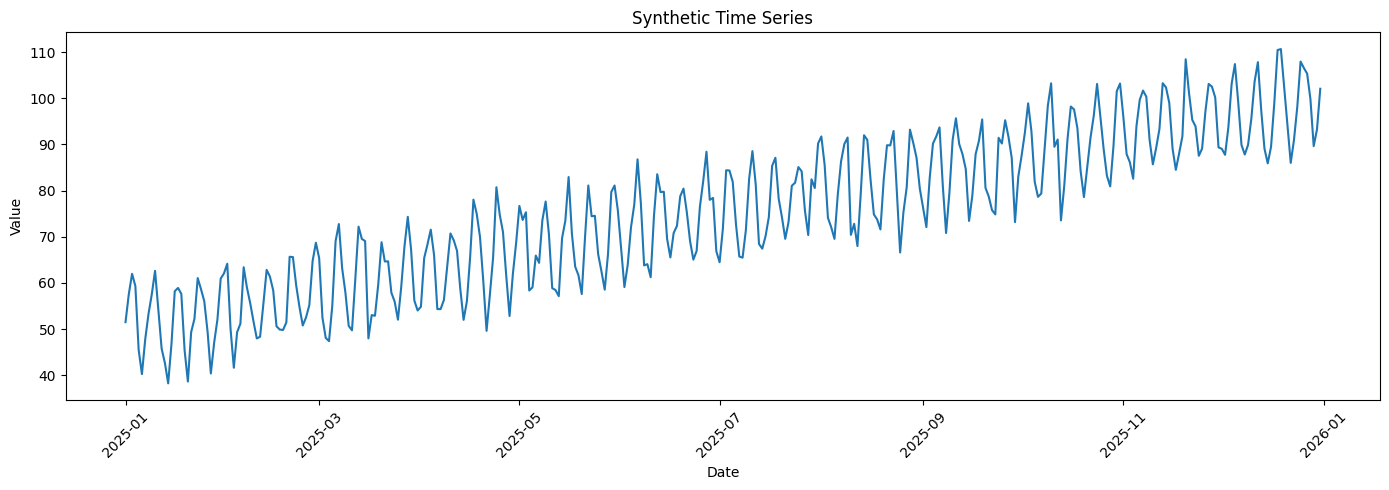

In [4]:
plt.figure(figsize=(14, 5))

plt.plot(
    df["date"],
    df["value"]
)

plt.title("Synthetic Time Series")
plt.xlabel("Date")
plt.ylabel("Value")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 10. Setting the Datetime Index

Time-series libraries work more naturally when the datetime variable is used as the index.

We first convert the column to a proper datetime type.

In [5]:
df["date"] = pd.to_datetime(df["date"])

df = df.set_index("date")

df.head()

,value
date,
2025-01-01,51.490142
2025-01-02,57.540885
2025-01-03,61.967070
2025-01-04,59.320015
2025-01-05,45.508153


In [6]:
df.index

DatetimeIndex(['2025-01-01', '2025-01-02', '2025-01-03', '2025-01-04',
               '2025-01-05', '2025-01-06', '2025-01-07', '2025-01-08',
               '2025-01-09', '2025-01-10',
               ...
               '2025-12-22', '2025-12-23', '2025-12-24', '2025-12-25',
               '2025-12-26', '2025-12-27', '2025-12-28', '2025-12-29',
               '2025-12-30', '2025-12-31'],
              dtype='datetime64[us]', name='date', length=365, freq=None)

## 11. Checking the Frequency

The frequency describes how frequently observations occur.

Our dataset contains daily observations.

Pandas provides useful functionality for identifying and working with time frequencies.

In [7]:
print("First date:", df.index.min())
print("Last date:", df.index.max())
print("Number of observations:", len(df))

print("\nTime differences:")
print(df.index.to_series().diff().value_counts().head())

First date: 2025-01-01 00:00:00
Last date: 2025-12-31 00:00:00
Number of observations: 365

Time differences:
date
1 days    364
Name: count, dtype: int64


## 12. Selecting Data by Date

Datetime indexing allows us to select observations using dates.

This is much more natural than selecting observations only by integer position.

In [8]:
df.loc["2025-01-01":"2025-01-15"]

,value
date,
2025-01-01,51.490142
2025-01-02,57.540885
2025-01-03,61.967070
2025-01-04,59.320015
2025-01-05,45.508153
2025-01-06,40.235123
2025-01-07,47.743499
2025-01-08,53.263843
2025-01-09,57.508793


In [9]:
df.loc["2025-06"]

,value
date,
2025-06-01,67.442265
2025-06-02,59.089768
2025-06-03,63.894930
2025-06-04,72.033064
2025-06-05,76.966469
2025-06-06,86.775174
2025-06-07,77.326270
2025-06-08,63.790549
2025-06-09,64.061041


## 13. Resampling

Resampling changes the frequency of a time series.

For example:

$$
\text{Daily} \rightarrow \text{Weekly}
$$

or:

$$
\text{Daily} \rightarrow \text{Monthly}
$$

Common operations include:

- Mean
- Sum
- Minimum
- Maximum
- First value
- Last value

The correct aggregation depends on the meaning of the variable.

For example:

- Revenue → usually sum
- Temperature → often mean
- Stock price → often last value for period-end price
- Inventory → often last value

In [10]:
weekly_mean = df["value"].resample("W").mean()

weekly_mean.head()

date
2025-01-05    55.165253
2025-01-12    51.637379
2025-01-19    49.675383
2025-01-26    52.180645
2025-02-02    53.798993
Freq: W-SUN, Name: value, dtype: float64

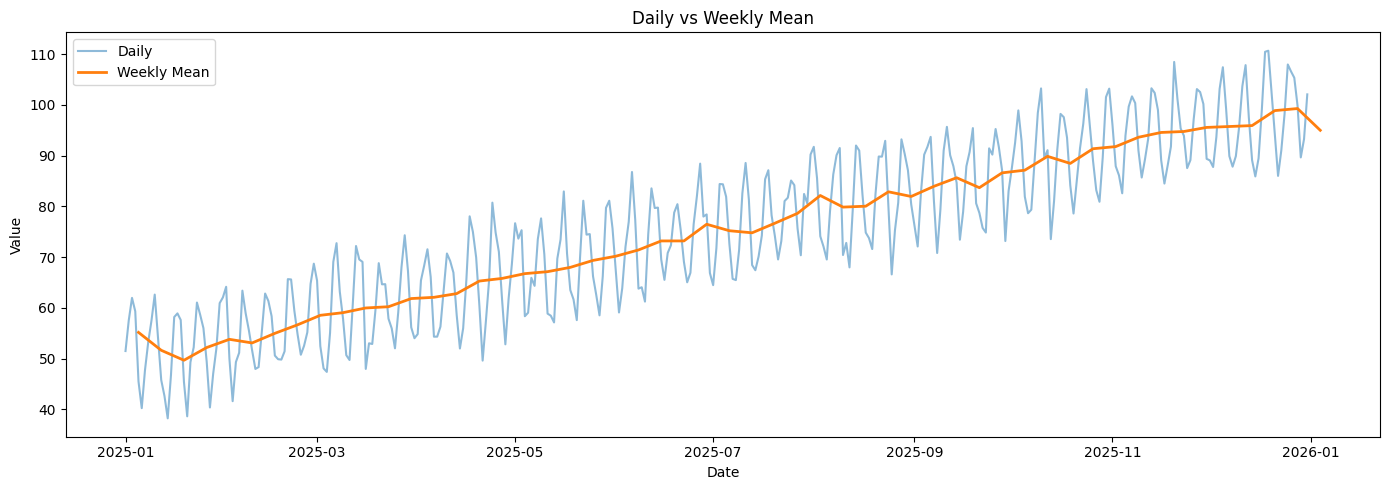

In [11]:
plt.figure(figsize=(14, 5))

plt.plot(
    df.index,
    df["value"],
    alpha=0.5,
    label="Daily"
)

plt.plot(
    weekly_mean.index,
    weekly_mean,
    label="Weekly Mean",
    linewidth=2
)

plt.title("Daily vs Weekly Mean")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()

plt.tight_layout()
plt.show()

## 14. Rolling Statistics

Rolling statistics calculate a statistic over a moving window.

For a rolling mean with window size $k$:

$$
MA_t =
\frac{1}{k}
\sum_{i=0}^{k-1}Y_{t-i}
$$

For example, a 7-day rolling mean uses the current observation and the previous six observations.

Rolling statistics are useful for:

- Smoothing noisy data
- Detecting trends
- Detecting changing variance
- Creating forecasting features
- Understanding local behavior

In [12]:
df["rolling_mean_7"] = (
    df["value"]
    .rolling(window=7)
    .mean()
)

df["rolling_std_7"] = (
    df["value"]
    .rolling(window=7)
    .std()
)

df.head(10)

,value,rolling_mean_7,rolling_std_7
date,,,
2025-01-01,51.490142,NaN,NaN
2025-01-02,57.540885,NaN,NaN
2025-01-03,61.967070,NaN,NaN
2025-01-04,59.320015,NaN,NaN
2025-01-05,45.508153,NaN,NaN
2025-01-06,40.235123,NaN,NaN
2025-01-07,47.743499,51.972127,7.984936
2025-01-08,53.263843,52.225513,7.995228
2025-01-09,57.508793,52.220928,7.991680


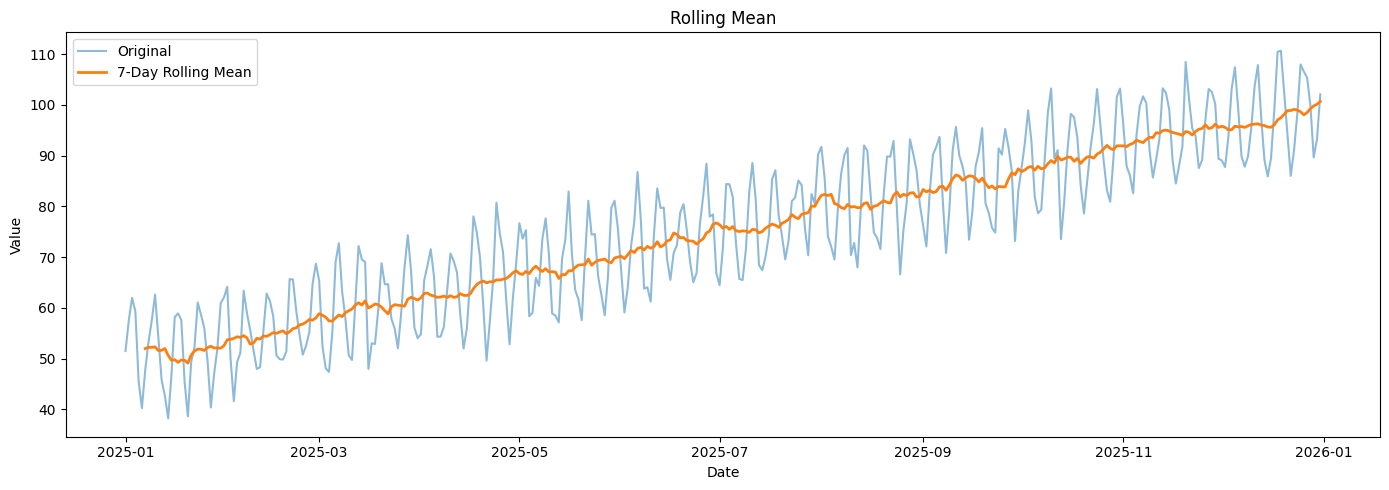

In [13]:
plt.figure(figsize=(14, 5))

plt.plot(
    df.index,
    df["value"],
    alpha=0.5,
    label="Original"
)

plt.plot(
    df.index,
    df["rolling_mean_7"],
    label="7-Day Rolling Mean",
    linewidth=2
)

plt.title("Rolling Mean")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()

plt.tight_layout()
plt.show()

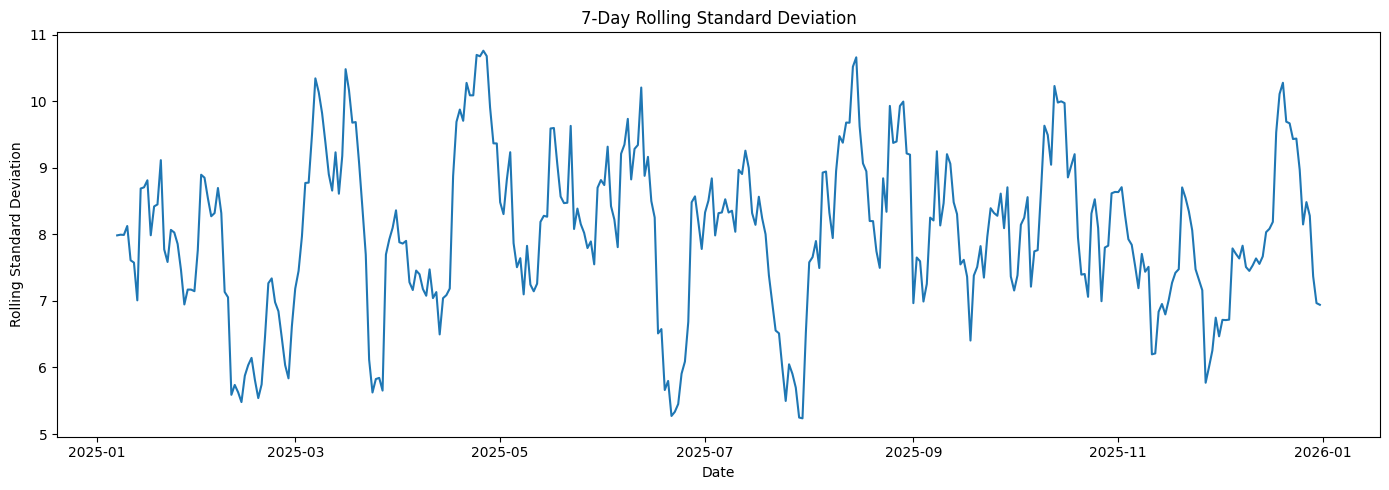

In [14]:
plt.figure(figsize=(14, 5))

plt.plot(
    df.index,
    df["rolling_std_7"]
)

plt.title("7-Day Rolling Standard Deviation")
plt.xlabel("Date")
plt.ylabel("Rolling Standard Deviation")

plt.tight_layout()
plt.show()

## 15. Lag Features

A lag represents a previous observation.

The lag-1 value is:

$$
Y_{t-1}
$$

The lag-7 value is:

$$
Y_{t-7}
$$

Lag features are fundamental in time-series machine learning and autoregressive models.

For example:

$$
Y_t = f(Y_{t-1},Y_{t-2},Y_{t-7}) + \epsilon_t
$$

In [15]:
df["lag_1"] = df["value"].shift(1)
df["lag_7"] = df["value"].shift(7)

df.head(10)

,value,rolling_mean_7,rolling_std_7,lag_1,lag_7
date,,,,,
2025-01-01,51.490142,NaN,NaN,NaN,NaN
2025-01-02,57.540885,NaN,NaN,51.490142,NaN
2025-01-03,61.967070,NaN,NaN,57.540885,NaN
2025-01-04,59.320015,NaN,NaN,61.967070,NaN
2025-01-05,45.508153,NaN,NaN,59.320015,NaN
2025-01-06,40.235123,NaN,NaN,45.508153,NaN
2025-01-07,47.743499,51.972127,7.984936,40.235123,NaN
2025-01-08,53.263843,52.225513,7.995228,47.743499,51.490142
2025-01-09,57.508793,52.220928,7.991680,53.263843,57.540885


### Important: Missing Values from Lagging

When we create a lag:

$$
Y_{t-1}
$$

the first observation has no previous value.

Therefore:

```text
lag_1
↓
NaN
value_1
value_2
value_3
...

Similarly, a lag of 7 produces seven missing values at the beginning.

These missing values must be handled before training a machine learning model.


---

## 16. Expanding Windows

An expanding window uses all observations available up to the current time.

For example:

```text
Time 1 → [1]
Time 2 → [1, 2]
Time 3 → [1, 2, 3]
Time 4 → [1, 2, 3, 4]

The expanding mean at time $t$ is:

$$ \bar{Y}_t = \frac{1}{t} \sum_{i=1}^{t}Y_i $$

Expanding windows are particularly useful in walk-forward forecasting and online learning scenarios.

In [16]:
df["expanding_mean"] = (
    df["value"]
    .expanding()
    .mean()
)

df[["value", "expanding_mean"]].head(15)

,value,expanding_mean
date,,
2025-01-01,51.490142,51.490142
2025-01-02,57.540885,54.515514
2025-01-03,61.967070,56.999366
2025-01-04,59.320015,57.579528
2025-01-05,45.508153,55.165253
2025-01-06,40.235123,52.676898
2025-01-07,47.743499,51.972127
2025-01-08,53.263843,52.133591
2025-01-09,57.508793,52.730836


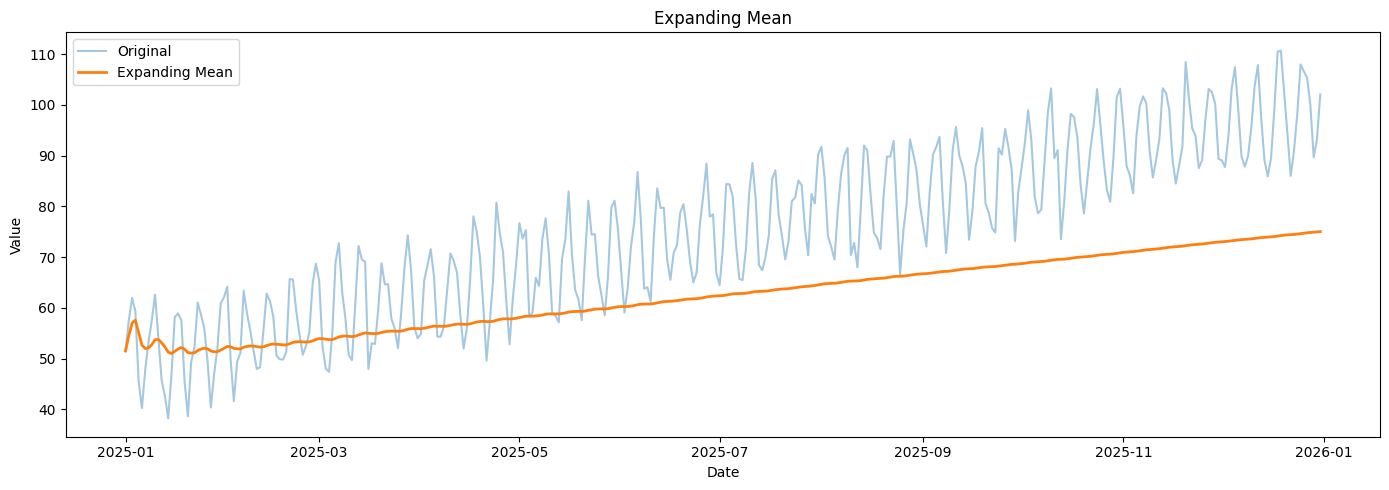

In [17]:
plt.figure(figsize=(14, 5))

plt.plot(
    df.index,
    df["value"],
    alpha=0.4,
    label="Original"
)

plt.plot(
    df.index,
    df["expanding_mean"],
    label="Expanding Mean",
    linewidth=2
)

plt.title("Expanding Mean")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()

plt.tight_layout()
plt.show()

# 17. Time-Series Decomposition — Preview

A time series can often be viewed as a combination of several components.

For an additive model:

$$
Y_t = T_t + S_t + R_t
$$

where:

- $T_t$ = trend
- $S_t$ = seasonality
- $R_t$ = residual

For a multiplicative model:

$$
Y_t = T_t \times S_t \times R_t
$$

The choice depends on how the seasonal variation behaves.

### Additive

Seasonal fluctuations remain approximately constant in magnitude.

### Multiplicative

Seasonal fluctuations grow or shrink with the level of the series.

We will study decomposition properly after introducing stationarity and time-series diagnostics.

# 18. Important Time-Series Principles

Before moving to statistical models, remember these principles.

### Principle 1 — Time order matters

Observations cannot generally be treated as exchangeable.

### Principle 2 — The future must not leak into the past

Features and preprocessing must be constructed using information available at prediction time.

### Principle 3 — Random train-test splitting is usually inappropriate

Use chronological splitting and time-aware validation.

### Principle 4 — Establish a baseline

A sophisticated model should outperform a simple forecasting strategy.

### Principle 5 — Understand the data before modeling

Always investigate:

- Trend
- Seasonality
- Missing observations
- Outliers
- Variance
- Autocorrelation
- Frequency

### Principle 6 — Forecast errors must be evaluated chronologically

The evaluation procedure should reproduce the way the model will actually be used.

## Section checkpoint

At this point your notebook has established the foundation:

```
Time Series
    │
    ├── Univariate / Multivariate
    │
    ├── Trend
    ├── Seasonality
    ├── Cycles
    └── Noise
          │
          ↓
    Datetime Handling
          │
          ├── Indexing
          ├── Resampling
          ├── Rolling Windows
          ├── Expanding Windows
          └── Lag Features

# 19. Stationarity

Stationarity is one of the most important concepts in classical time-series analysis.

A stationary time series has statistical properties that remain stable over time.

In particular, for weak stationarity:

### Constant Mean

$$
E[Y_t] = \mu
$$

The expected value does not depend on time.

### Constant Variance

$$
Var(Y_t) = \sigma^2
$$

The variance does not depend on time.

### Time-Invariant Autocovariance

$$
Cov(Y_t,Y_{t-k}) = \gamma_k
$$

The covariance between observations depends only on the lag $k$, not on the specific time $t$.

Therefore:

$$
\boxed{
\text{Stationarity} =
\text{stable statistical properties over time}
}
$$

## 20. Why Is Stationarity Important?

Many classical time-series models assume that the underlying series is stationary or can be transformed into a stationary series.

If a series contains a strong trend:

$$
Y_t = \beta_0 + \beta_1t + \epsilon_t
$$

then its mean changes over time.

This violates the constant-mean assumption.

Similarly, changing variance can violate the constant-variance assumption.

A non-stationary series can produce:

- misleading correlations
- unreliable statistical inference
- unstable model parameters
- poor forecasts
- spurious regression relationships

Therefore, a common workflow is:

$$
\text{Original Series}
\rightarrow
\text{Stationarity Check}
\rightarrow
\text{Transformation}
\rightarrow
\text{Model}
$$

## 21. Strict vs Weak Stationarity

### Strict Stationarity

A process is strictly stationary if the joint probability distribution remains unchanged under a shift in time.

For any collection of times:

$$
(t_1,t_2,\ldots,t_n)
$$

and any shift $h$:

$$
(Y_{t_1},Y_{t_2},\ldots,Y_{t_n})
$$

has the same joint distribution as:

$$
(Y_{t_1+h},Y_{t_2+h},\ldots,Y_{t_n+h})
$$

Strict stationarity is a strong condition and is often difficult to verify in practice.

---

### Weak Stationarity

Weak stationarity requires:

$$
E[Y_t] = \mu
$$

$$
Var(Y_t) = \sigma^2
$$

and:

$$
Cov(Y_t,Y_{t-k}) = \gamma_k
$$

where these quantities do not depend on $t$.

Most classical time-series analysis works with this weaker concept.

### Practical Focus

In this notebook, we will primarily work with **weak stationarity**.

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# 22. Creating Stationary and Non-Stationary Series

We will create two synthetic series:

1. A stationary series
2. A non-stationary random walk

This helps us understand stationarity visually before using statistical tests.

In [19]:
n = 300

# Stationary series
stationary = np.random.normal(
    loc=0,
    scale=1,
    size=n
)

# Random walk
random_walk = np.cumsum(
    np.random.normal(
        loc=0,
        scale=1,
        size=n
    )
)

dates = pd.date_range(
    start="2025-01-01",
    periods=n,
    freq="D"
)

stationarity_df = pd.DataFrame(
    {
        "stationary": stationary,
        "random_walk": random_walk
    },
    index=dates
)

stationarity_df.head()

,stationary,random_walk
2025-01-01,0.496714,-0.828995
2025-01-02,-0.138264,-1.389176
2025-01-03,0.647689,-0.641882
2025-01-04,1.523030,-0.031512
2025-01-05,-0.234153,-0.052414


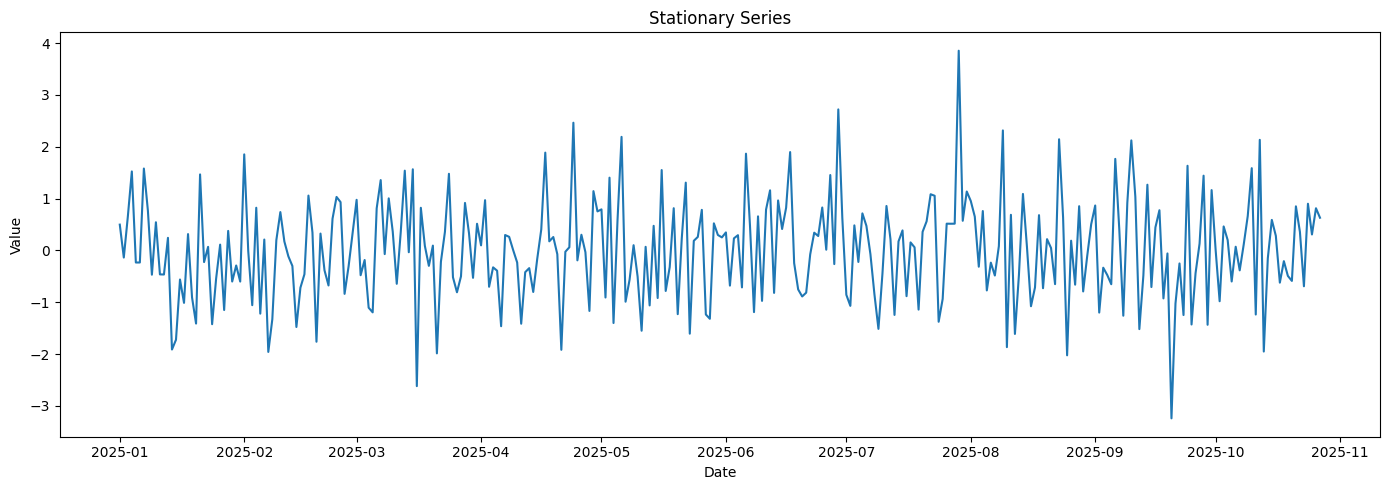

In [20]:
plt.figure(figsize=(14, 5))

plt.plot(
    stationarity_df.index,
    stationarity_df["stationary"]
)

plt.title("Stationary Series")
plt.xlabel("Date")
plt.ylabel("Value")

plt.tight_layout()
plt.show()

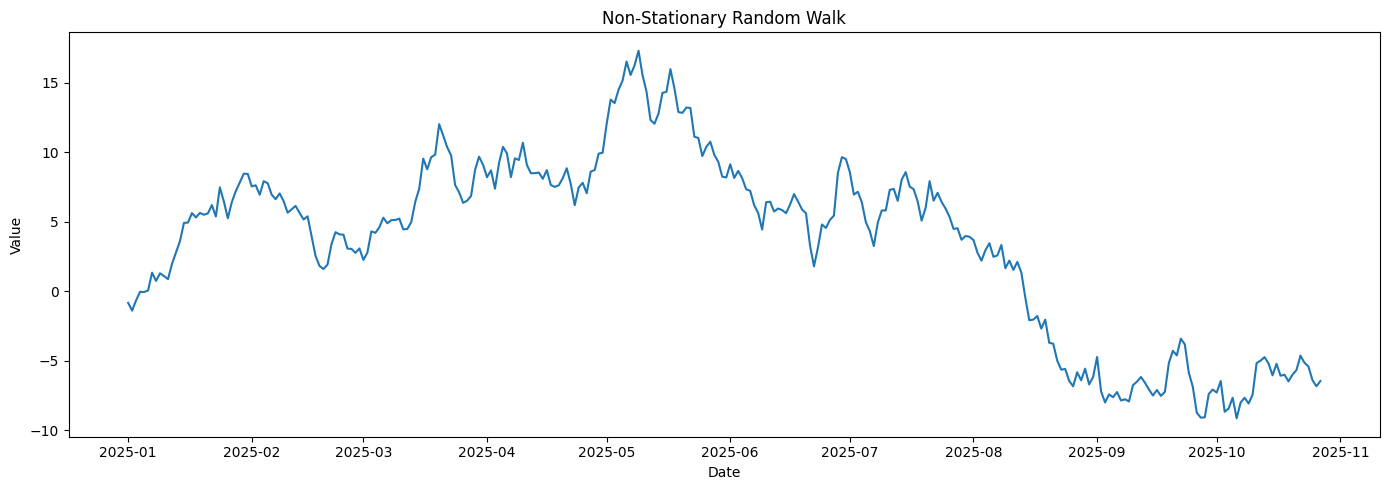

In [21]:
plt.figure(figsize=(14, 5))

plt.plot(
    stationarity_df.index,
    stationarity_df["random_walk"]
)

plt.title("Non-Stationary Random Walk")
plt.xlabel("Date")
plt.ylabel("Value")

plt.tight_layout()
plt.show()

### Interpretation

The stationary series fluctuates around a relatively stable mean.

The random walk does not remain around a fixed mean. Instead, shocks accumulate over time:

$$
Y_t = Y_{t-1} + \epsilon_t
$$

where:

$$
\epsilon_t \sim WN(0,\sigma^2)
$$

This creates a non-stationary process.

A random walk is one of the simplest examples of a non-stationary time series.

## 23. Visual Diagnostics for Stationarity

Before using statistical tests, visual inspection is useful.

We can examine:

- Rolling mean
- Rolling variance
- Rolling standard deviation
- Overall trend
- Changes in variability

If the rolling mean changes substantially over time, this may indicate non-stationarity.

If the rolling standard deviation changes substantially over time, the variance may not be stable.

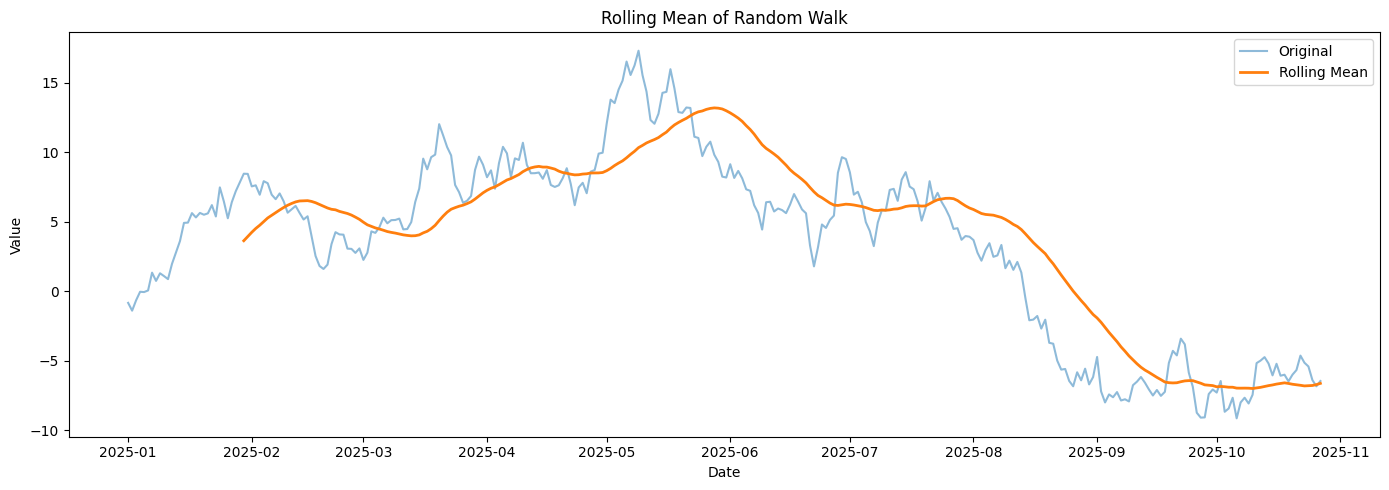

In [22]:
rolling_mean = (
    stationarity_df["random_walk"]
    .rolling(window=30)
    .mean()
)

rolling_std = (
    stationarity_df["random_walk"]
    .rolling(window=30)
    .std()
)

plt.figure(figsize=(14, 5))

plt.plot(
    stationarity_df.index,
    stationarity_df["random_walk"],
    alpha=0.5,
    label="Original"
)

plt.plot(
    stationarity_df.index,
    rolling_mean,
    label="Rolling Mean",
    linewidth=2
)

plt.title("Rolling Mean of Random Walk")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()

plt.tight_layout()
plt.show()

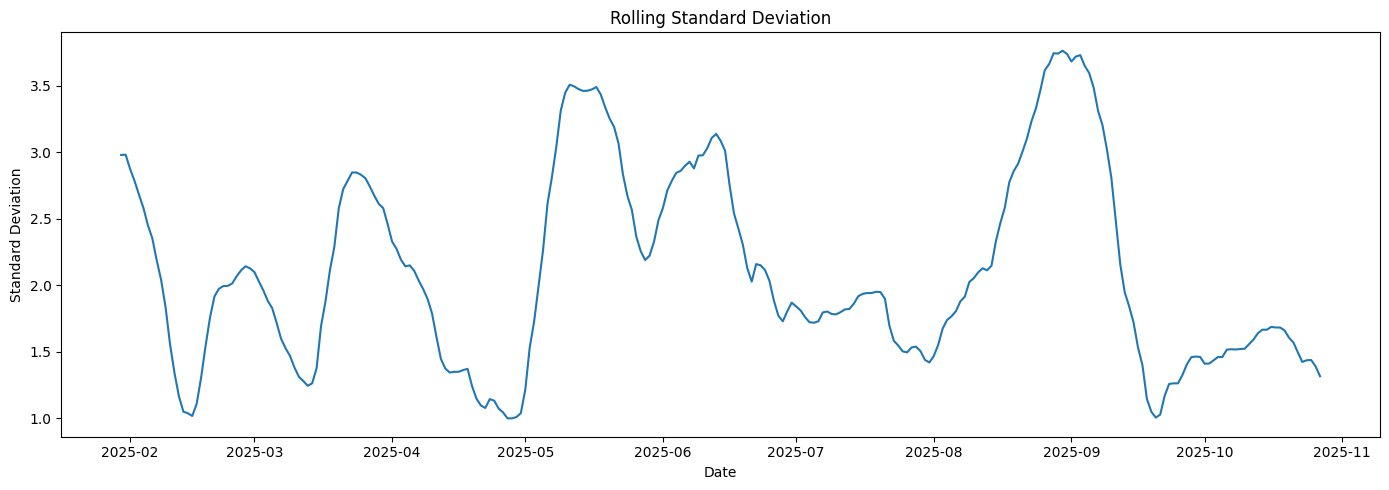

In [23]:
plt.figure(figsize=(14, 5))

plt.plot(
    stationarity_df.index,
    rolling_std
)

plt.title("Rolling Standard Deviation")
plt.xlabel("Date")
plt.ylabel("Standard Deviation")

plt.tight_layout()
plt.show()

# 24. Differencing

Differencing is one of the most important techniques for converting a non-stationary series into a stationary one.

First-order differencing is defined as:

$$
\Delta Y_t = Y_t - Y_{t-1}
$$

or:

$$
\Delta Y_t = (1-B)Y_t
$$

where $B$ is the backshift operator.

The backshift operator is defined as:

$$
BY_t = Y_{t-1}
$$

Therefore:

$$
(1-B)Y_t
=
Y_t-BY_t
=
Y_t-Y_{t-1}
$$

---

### Second-Order Differencing

If first-order differencing is not sufficient:

$$
\Delta^2Y_t
=
\Delta Y_t-\Delta Y_{t-1}
$$

which is:

$$
\Delta^2Y_t
=
Y_t-2Y_{t-1}+Y_{t-2}
$$

In practice, we should avoid unnecessary differencing.

> **Over-differencing can remove useful information and introduce undesirable dependence.**

In [24]:
random_walk_diff = (
    stationarity_df["random_walk"]
    .diff()
)

random_walk_diff.head()

2025-01-01         NaN
2025-01-02   -0.560181
2025-01-03    0.747294
2025-01-04    0.610370
2025-01-05   -0.020902
Freq: D, Name: random_walk, dtype: float64

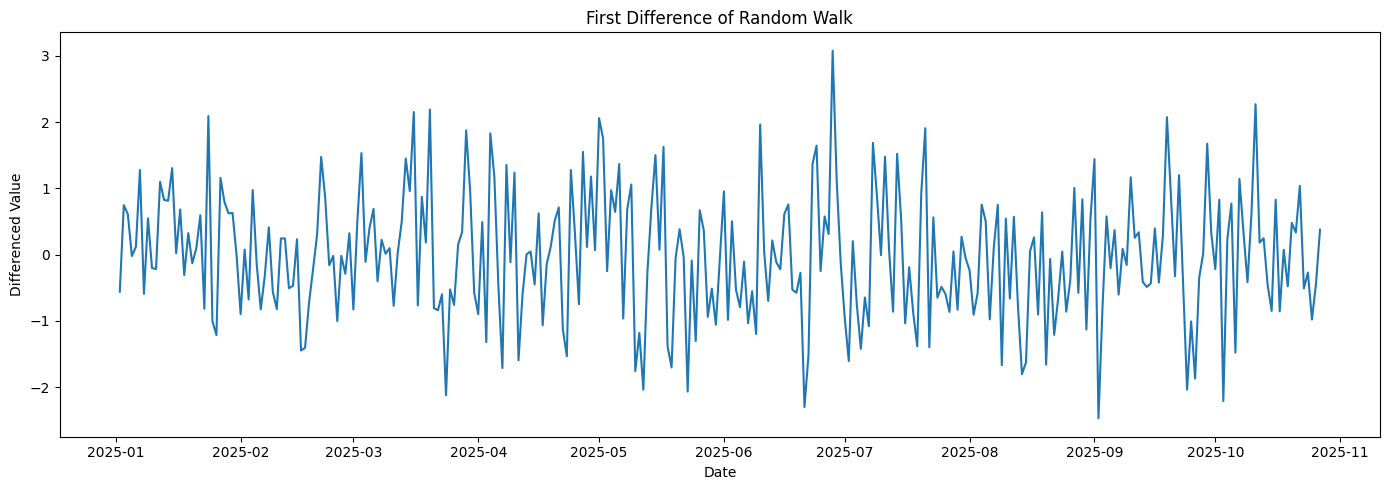

In [25]:
plt.figure(figsize=(14, 5))

plt.plot(
    random_walk_diff
)

plt.title("First Difference of Random Walk")
plt.xlabel("Date")
plt.ylabel("Differenced Value")

plt.tight_layout()
plt.show()

### Interpretation

The original random walk was non-stationary:

$$
Y_t = Y_{t-1}+\epsilon_t
$$

After differencing:

$$
\Delta Y_t
=
Y_t-Y_{t-1}
=
\epsilon_t
$$

The differenced series is therefore approximately white noise and is stationary.

This is the fundamental intuition behind the **I component of ARIMA**.

The value $d$ in:

$$
ARIMA(p,d,q)
$$

represents the number of differences applied to make the series approximately stationary.

# 25. Augmented Dickey-Fuller (ADF) Test

The Augmented Dickey-Fuller test is commonly used to test for a unit root.

The hypotheses are:

$$
H_0:
\text{The series has a unit root}
$$

$$
H_1:
\text{The series is stationary}
$$

### Interpretation

If:

$$
p < \alpha
$$

we reject $H_0$ and conclude that there is evidence of stationarity.

If:

$$
p \geq \alpha
$$

we fail to reject $H_0$.

A common significance level is:

$$
\alpha = 0.05
$$

### Important

Failing to reject $H_0$ does **not** prove that the series is non-stationary.

It means there is insufficient evidence to reject the unit-root hypothesis.

In [27]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name="Series"):
    series = series.dropna()

    result = adfuller(series)

    print(f"ADF Test: {name}")
    print("-" * 40)
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value:       {result[1]:.4f}")
    print(f"Lags Used:     {result[2]}")
    print(f"Observations:  {result[3]}")

    print("\nCritical Values:")

    for key, value in result[4].items():
        print(f"  {key}: {value:.4f}")

    if result[1] < 0.05:
        print("\nConclusion: Reject H0 → evidence of stationarity.")
    else:
        print("\nConclusion: Fail to reject H0 → evidence of non-stationarity.")

In [28]:
adf_test(
    stationarity_df["stationary"],
    "Stationary Series"
)

ADF Test: Stationary Series
----------------------------------------
ADF Statistic: -18.6316
p-value:       0.0000
Lags Used:     0
Observations:  299

Critical Values:
  1%: -3.4524
  5%: -2.8713
  10%: -2.5719

Conclusion: Reject H0 → evidence of stationarity.


C:\Users\soumy\AppData\Local\Temp\ipykernel_14804\420272714.py:6: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(series)


In [29]:
adf_test(
    stationarity_df["random_walk"],
    "Random Walk"
)

ADF Test: Random Walk
----------------------------------------
ADF Statistic: -0.9053
p-value:       0.7862
Lags Used:     0
Observations:  299

Critical Values:
  1%: -3.4524
  5%: -2.8713
  10%: -2.5719

Conclusion: Fail to reject H0 → evidence of non-stationarity.


C:\Users\soumy\AppData\Local\Temp\ipykernel_14804\420272714.py:6: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(series)


In [30]:
adf_test(
    random_walk_diff,
    "Differenced Random Walk"
)

ADF Test: Differenced Random Walk
----------------------------------------
ADF Statistic: -16.1872
p-value:       0.0000
Lags Used:     0
Observations:  298

Critical Values:
  1%: -3.4525
  5%: -2.8713
  10%: -2.5720

Conclusion: Reject H0 → evidence of stationarity.


C:\Users\soumy\AppData\Local\Temp\ipykernel_14804\420272714.py:6: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(series)


# 26. KPSS Test

The KPSS test complements the ADF test.

Its hypotheses are essentially reversed.

### KPSS Null Hypothesis

$$
H_0:
\text{The series is stationary}
$$

### Alternative Hypothesis

$$
H_1:
\text{The series is non-stationary}
$$

Therefore:

| Test | Null Hypothesis |
|---|---|
| ADF | Non-stationary |
| KPSS | Stationary |

Using both tests can provide stronger evidence than relying on only one test.

In [31]:
from statsmodels.tsa.stattools import kpss

def kpss_test(series, name="Series"):
    series = series.dropna()

    statistic, p_value, lags, critical_values = kpss(
        series,
        regression="c",
        nlags="auto"
    )

    print(f"KPSS Test: {name}")
    print("-" * 40)
    print(f"KPSS Statistic: {statistic:.4f}")
    print(f"p-value:        {p_value:.4f}")
    print(f"Lags Used:      {lags}")

    print("\nCritical Values:")

    for key, value in critical_values.items():
        print(f"  {key}: {value}")

    if p_value < 0.05:
        print("\nConclusion: Reject H0 → evidence of non-stationarity.")
    else:
        print("\nConclusion: Fail to reject H0 → evidence of stationarity.")

In [32]:
kpss_test(
    stationarity_df["stationary"],
    "Stationary Series"
)

KPSS Test: Stationary Series
----------------------------------------
KPSS Statistic: 0.1815
p-value:        0.1000
Lags Used:      1

Critical Values:
  10%: 0.347
  5%: 0.463
  2.5%: 0.574
  1%: 0.739

Conclusion: Fail to reject H0 → evidence of stationarity.


C:\Users\soumy\AppData\Local\Temp\ipykernel_14804\749582379.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  statistic, p_value, lags, critical_values = kpss(
C:\Users\soumy\AppData\Local\Temp\ipykernel_14804\749582379.py:6: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which silently drops `lags` when store=True). In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning a KPSSResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  statistic, p_value, lags, critical_values = kpss(


In [33]:
kpss_test(
    stationarity_df["random_walk"],
    "Random Walk"
)

KPSS Test: Random Walk
----------------------------------------
KPSS Statistic: 1.4725
p-value:        0.0100
Lags Used:      10

Critical Values:
  10%: 0.347
  5%: 0.463
  2.5%: 0.574
  1%: 0.739

Conclusion: Reject H0 → evidence of non-stationarity.


C:\Users\soumy\AppData\Local\Temp\ipykernel_14804\749582379.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  statistic, p_value, lags, critical_values = kpss(
C:\Users\soumy\AppData\Local\Temp\ipykernel_14804\749582379.py:6: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which silently drops `lags` when store=True). In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning a KPSSResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  statistic, p_value, lags, critical_values = kpss(


# 27. Combining ADF and KPSS

Using both tests gives a useful diagnostic framework.

| ADF | KPSS | Interpretation |
|---|---|---|
| Reject $H_0$ | Fail to reject $H_0$ | Strong evidence of stationarity |
| Fail to reject $H_0$ | Reject $H_0$ | Strong evidence of non-stationarity |
| Reject $H_0$ | Reject $H_0$ | Possible trend / structural issues |
| Fail to reject $H_0$ | Fail to reject $H_0$ | Tests are inconclusive |

The tests should not be treated as absolute truth.

Always combine:

$$
\boxed{
\text{Visual Analysis}
+
\text{Statistical Tests}
+
\text{Domain Knowledge}
}
$$

when determining whether a series is stationary.

# 28. Autocorrelation

Autocorrelation measures the relationship between a time series and its lagged values.

For lag $k$:

$$
\rho_k =
\frac{Cov(Y_t,Y_{t-k})}
{\sqrt{Var(Y_t)Var(Y_{t-k})}}
$$

For a stationary series with constant variance:

$$
\rho_k =
\frac{\gamma_k}{\gamma_0}
$$

where:

- $\gamma_k$ = autocovariance at lag $k$
- $\gamma_0$ = variance of the series

### Interpretation

If:

$$
\rho_1 \approx 1
$$

then consecutive observations are strongly positively related.

If:

$$
\rho_1 \approx -1
$$

then consecutive observations have a strong negative relationship.

If:

$$
\rho_k \approx 0
$$

there is little linear relationship at lag $k$.

# 29. Lagged Relationship

Consider:

$$
Y_t
$$

and:

$$
Y_{t-1}
$$

The correlation between them tells us how strongly the current value is related to the previous value.

Similarly:

$$
Y_t \leftrightarrow Y_{t-2}
$$

measures the relationship at lag 2.

And:

$$
Y_t \leftrightarrow Y_{t-k}
$$

measures the relationship at lag $k$.

This produces the **Autocorrelation Function (ACF)**.

<Figure size 1200x500 with 0 Axes>

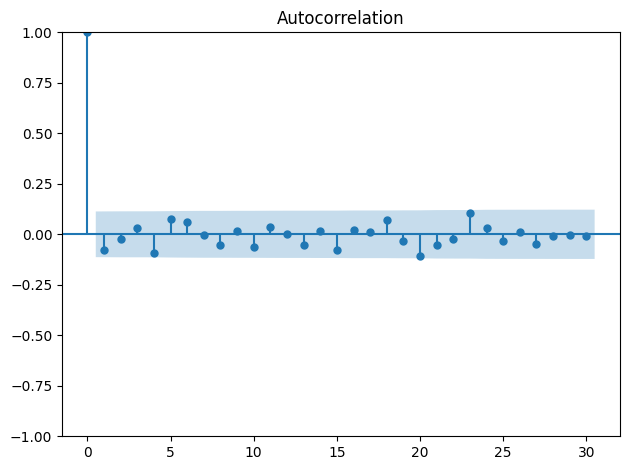

In [34]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(12, 5))

plot_acf(
    stationarity_df["stationary"],
    lags=30
)

plt.tight_layout()
plt.show()

<Figure size 1200x500 with 0 Axes>

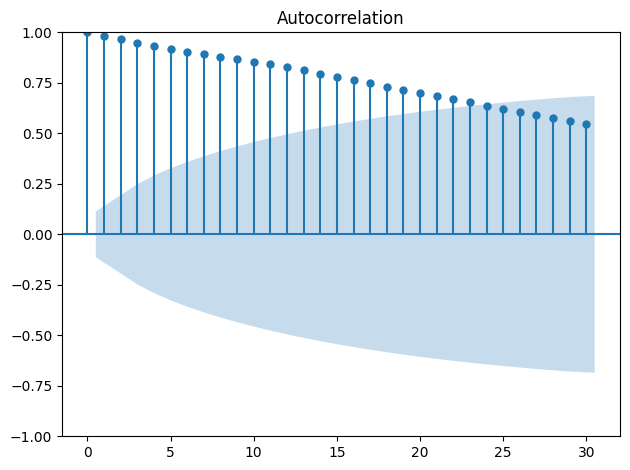

In [35]:
plt.figure(figsize=(12, 5))

plot_acf(
    stationarity_df["random_walk"],
    lags=30
)

plt.tight_layout()
plt.show()

<Figure size 1200x500 with 0 Axes>

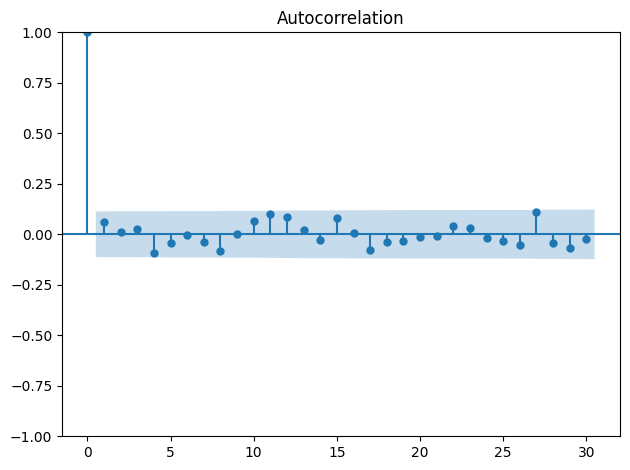

In [36]:
plt.figure(figsize=(12, 5))

plot_acf(
    random_walk_diff.dropna(),
    lags=30
)

plt.tight_layout()
plt.show()

## 30. Understanding the ACF

The ACF plot shows correlation against different lags.

For example:

```text
Lag     Correlation
-------------------
0       1.00
1       0.82
2       0.65
3       0.51
...

Typical Patterns:

A stationary series often has an ACF that eventually decreases toward zero.

A random walk tends to have very high autocorrelation across many lags.

After differencing a random walk, the autocorrelation becomes much weaker.

This makes ACF a useful diagnostic for stationarity and model identification.


---


# 31. Partial Autocorrelation Function (PACF)

PACF measures the relationship between:

$$
Y_t
$$

and:

$$
Y_{t-k}
$$

after controlling for the effects of intermediate lags.

For example, the PACF at lag 3 measures the direct relationship between:

$$
Y_t
$$

and:

$$
Y_{t-3}
$$

after accounting for:

$$
Y_{t-1}
$$

and:

$$
Y_{t-2}
$$

PACF is especially useful for identifying the autoregressive order $p$ in AR models.

<Figure size 1200x500 with 0 Axes>

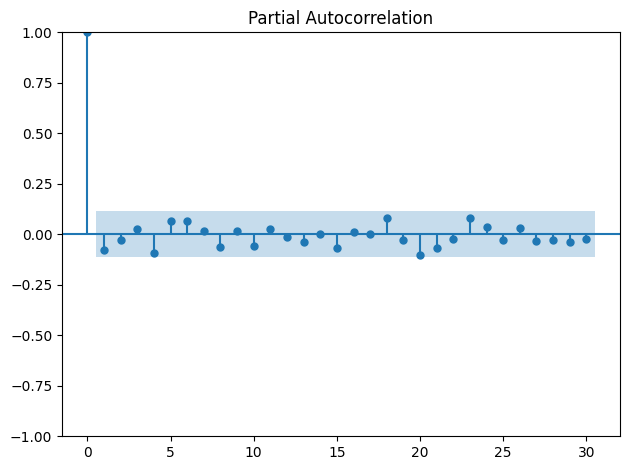

In [37]:
from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(12, 5))

plot_pacf(
    stationarity_df["stationary"],
    lags=30,
    method="ywm"
)

plt.tight_layout()
plt.show()

# 32. ACF vs PACF

| Feature | ACF | PACF |
|---|---|---|
| Measures | Total lagged correlation | Direct lagged correlation |
| Controls intermediate lags | No | Yes |
| Useful for | MA identification | AR identification |
| Common model parameter | $q$ | $p$ |

A common rule of thumb:

### AR(p)

PACF tends to cut off after lag $p$.

### MA(q)

ACF tends to cut off after lag $q$.

### ARMA(p,q)

Both ACF and PACF tend to decay rather than showing a simple cutoff.

These are identification heuristics, not absolute rules.

# 33. White Noise

A white-noise process is a sequence of random variables with:

$$
E[\epsilon_t] = 0
$$

$$
Var(\epsilon_t) = \sigma^2
$$

and:

$$
Cov(\epsilon_t,\epsilon_{t-k}) = 0
\quad \text{for } k \neq 0
$$

Therefore:

$$
\rho_k = 0
\quad \text{for } k \neq 0
$$

White noise contains no predictable linear temporal structure.

A forecasting model should ideally leave residuals that resemble white noise.

In other words:

$$
\boxed{
\text{Good Model}
\Rightarrow
\text{Residuals contain little predictable structure}
}
$$

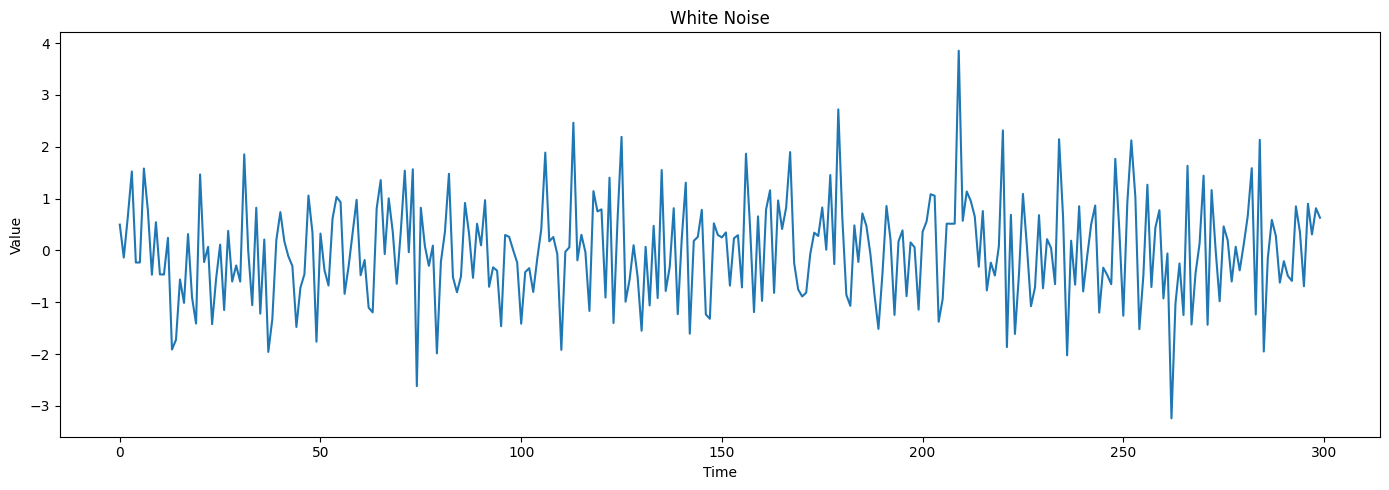

In [38]:
np.random.seed(42)

white_noise = np.random.normal(
    loc=0,
    scale=1,
    size=300
)

plt.figure(figsize=(14, 5))

plt.plot(
    white_noise
)

plt.title("White Noise")
plt.xlabel("Time")
plt.ylabel("Value")

plt.tight_layout()
plt.show()

<Figure size 1200x500 with 0 Axes>

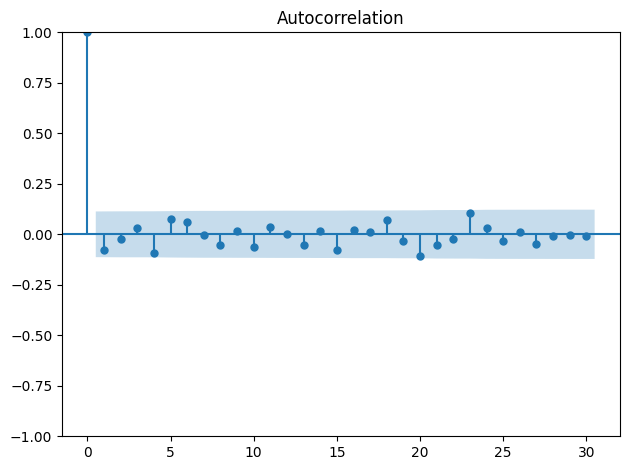

In [39]:
plt.figure(figsize=(12, 5))

plot_acf(
    white_noise,
    lags=30
)

plt.tight_layout()
plt.show()

# 34. Ljung-Box Test

The Ljung-Box test checks whether a group of autocorrelations is jointly different from zero.

The null hypothesis is:

$$
H_0:
\text{No autocorrelation up to the selected lag}
$$

The alternative hypothesis is:

$$
H_1:
\text{Autocorrelation exists}
$$

If:

$$
p < 0.05
$$

we reject $H_0$ and conclude that there is evidence of autocorrelation.

For model residuals, we generally want:

$$
p \geq 0.05
$$

because we do not want significant remaining autocorrelation.

However, this does not prove that the model is perfect.

In [40]:
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_box_result = acorr_ljungbox(
    white_noise,
    lags=[10, 20],
    return_df=True
)

ljung_box_result

,lb_stat,lb_pvalue
10,10.159188,0.426640
20,19.346650,0.499407


# 35. Stationarity Workflow

A practical workflow is:

```text
Raw Time Series
      ↓
Visualize
      ↓
Check Trend / Seasonality
      ↓
Check Rolling Mean / Variance
      ↓
ADF + KPSS
      ↓
Stationary?
   ┌──┴──┐
  Yes    No
   │      │
   │   Transform
   │      │
   │   Differencing
   │      │
   └──┬───┘
      ↓
  ACF / PACF
      ↓
 Model Selection

Possible transformations include:

    Differencing
    Log transformation
    Square-root transformation
    Box-Cox transformation
    Seasonal differencing


---


# 36. Important Distinction: Stationarity vs Seasonality

Stationarity and seasonality are related but not identical.

A series can have:

- Trend without seasonality
- Seasonality without trend
- Both trend and seasonality
- Neither trend nor seasonality

For example, a series with stable weekly seasonal fluctuations may still require seasonal modeling.

Seasonality can often be handled using:

$$
\text{Seasonal Differencing}
$$

defined as:

$$
\Delta_m Y_t
=
Y_t-Y_{t-m}
$$

where $m$ is the seasonal period.

For daily data with weekly seasonality:

$$
m=7
$$

and:

$$
\Delta_7Y_t
=
Y_t-Y_{t-7}
$$

# 37. Key Takeaways

### Stationarity

A stationary series has stable statistical properties over time.

### Differencing

Differencing can remove stochastic trends:

$$
\Delta Y_t=Y_t-Y_{t-1}
$$

### ADF

ADF tests:

$$
H_0=\text{unit root / non-stationarity}
$$

### KPSS

KPSS tests:

$$
H_0=\text{stationarity}
$$

### ACF

Measures correlation between observations and their lags.

### PACF

Measures direct lagged relationships after accounting for intermediate lags.

### White Noise

Contains no meaningful autocorrelation.

### Residual Diagnostics

A good forecasting model should leave residuals with little systematic temporal structure.

## Where we are now

Your notebook now has the full conceptual chain:

```
Time Series
     ↓
Components
     ↓
Datetime Handling
     ↓
Rolling / Lag Features
     ↓
Stationarity
     ↓
Differencing
     ↓
ADF / KPSS
     ↓
Autocorrelation
     ↓
ACF / PACF
     ↓
White Noise
     ↓
Ljung-Box
     ↓
MODEL IDENTIFICATION

# 38. Autoregressive (AR) Models

An autoregressive model predicts the current value of a time series using its own previous values.

The name comes from:

- **Auto** → the series itself
- **Regressive** → regression on previous observations

An AR($p$) model is:

$$
Y_t =
c +
\phi_1Y_{t-1}
+
\phi_2Y_{t-2}
+
\cdots
+
\phi_pY_{t-p}
+
\epsilon_t
$$

where:

- $Y_t$ = current observation
- $c$ = intercept
- $\phi_i$ = autoregressive coefficients
- $p$ = number of lags
- $\epsilon_t$ = random error

The key idea is:

$$
\boxed{
\text{Current value}
\approx
\text{function of previous values}
}
$$

# 39. AR(1) Model

The simplest autoregressive model is AR(1):

$$
Y_t = c + \phi Y_{t-1} + \epsilon_t
$$

There is only one lag.

For example:

$$
Y_t = 0.5 + 0.8Y_{t-1}+\epsilon_t
$$

This means the current observation depends strongly on the previous observation.

### Stationarity Condition

For an AR(1) process to be stationary:

$$
|\phi| < 1
$$

If:

$$
|\phi| \geq 1
$$

the process is not stationary in the usual AR(1) sense.

### Intuition

If:

$$
\phi \approx 0
$$

the previous observation has little influence.

If:

$$
\phi \approx 1
$$

the series has strong persistence.

If:

$$
\phi < 0
$$

successive observations tend to move in opposite directions.

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

n = 300
phi = 0.8

epsilon = np.random.normal(
    loc=0,
    scale=1,
    size=n
)

ar1 = np.zeros(n)

for t in range(1, n):
    ar1[t] = phi * ar1[t - 1] + epsilon[t]

ar1_series = pd.Series(ar1)

ar1_series.head()

0    0.000000
1   -0.138264
2    0.537077
3    1.952692
4    1.328000
dtype: float64

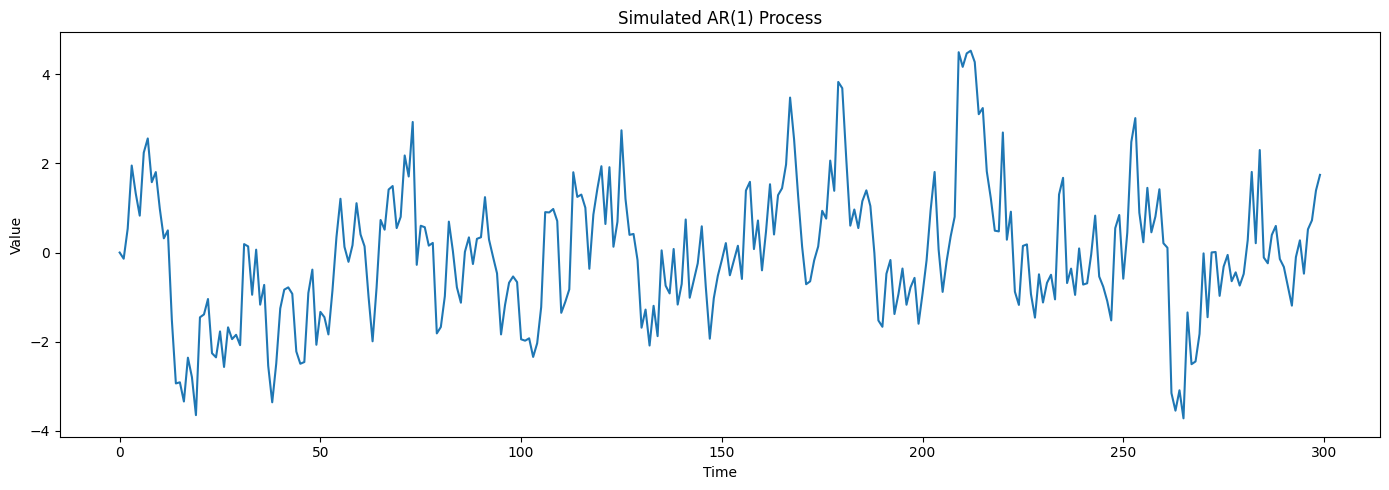

In [42]:
plt.figure(figsize=(14, 5))

plt.plot(ar1_series)

plt.title("Simulated AR(1) Process")
plt.xlabel("Time")
plt.ylabel("Value")

plt.tight_layout()
plt.show()

<Figure size 1200x500 with 0 Axes>

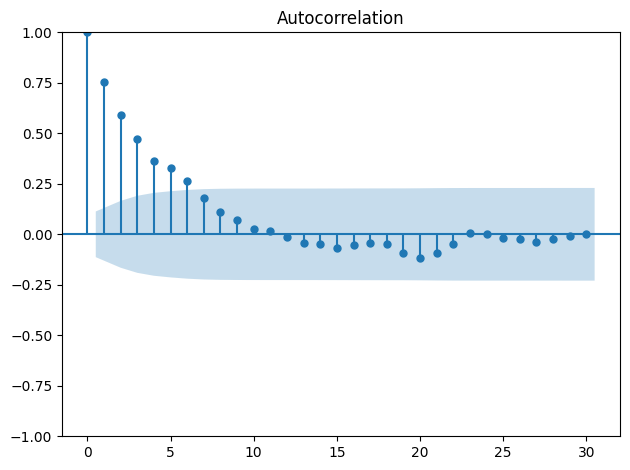

In [43]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(12, 5))

plot_acf(
    ar1_series,
    lags=30
)

plt.tight_layout()
plt.show()

<Figure size 1200x500 with 0 Axes>

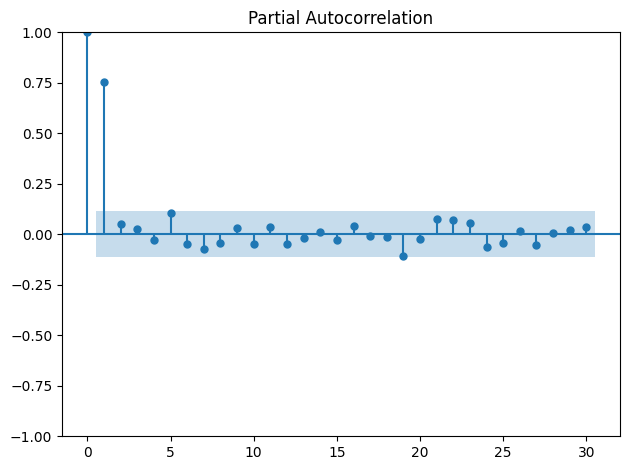

In [44]:
plt.figure(figsize=(12, 5))

plot_pacf(
    ar1_series,
    lags=30,
    method="ywm"
)

plt.tight_layout()
plt.show()

### AR(1) ACF/PACF Pattern

For a typical AR process:

- ACF gradually decays
- PACF approximately cuts off after lag $p$

For AR(1):

$$
\text{PACF} \rightarrow \text{strong spike at lag 1}
$$

followed by relatively small partial correlations.

This is one of the main reasons PACF is useful when selecting the AR order.

# 40. AR(p)

An AR($p$) model uses the previous $p$ observations:

$$
Y_t =
c+
\phi_1Y_{t-1}
+\phi_2Y_{t-2}
+\cdots+
\phi_pY_{t-p}
+\epsilon_t
$$

For example, AR(3):

$$
Y_t =
c+
\phi_1Y_{t-1}
+\phi_2Y_{t-2}
+\phi_3Y_{t-3}
+\epsilon_t
$$

The order $p$ determines how much historical information is directly used.

### Choosing $p$

A common initial diagnostic is PACF.

If PACF has significant spikes up to approximately lag $p$ and then cuts off, AR($p$) may be a reasonable candidate.

However:

> ACF/PACF should be treated as model-identification guides, not as an automatic model-selection algorithm.

# 41. Moving Average (MA) Models

A Moving Average model predicts the current observation using current and previous error terms.

An MA($q$) model is:

$$
Y_t =
\mu
+
\epsilon_t
+
\theta_1\epsilon_{t-1}
+
\theta_2\epsilon_{t-2}
+\cdots+
\theta_q\epsilon_{t-q}
$$

where:

- $\mu$ = mean
- $\theta_i$ = moving-average coefficients
- $q$ = MA order
- $\epsilon_t$ = error term

The important distinction is:

### AR

Uses previous **observations**:

$$
Y_{t-1},Y_{t-2},\ldots
$$

### MA

Uses previous **errors**:

$$
\epsilon_{t-1},\epsilon_{t-2},\ldots
$$

# 42. MA(1) Model

An MA(1) model is:

$$
Y_t =
\mu+\epsilon_t+\theta\epsilon_{t-1}
$$

The current observation is affected by:

1. The current random shock
2. The previous random shock

Unlike AR models, an MA model has a finite memory in terms of past shocks.

For an MA($q$) process, the ACF theoretically cuts off after lag $q$.

In [45]:
np.random.seed(42)

n = 300
theta = 0.7

epsilon = np.random.normal(
    loc=0,
    scale=1,
    size=n + 1
)

ma1 = (
    epsilon[1:]
    + theta * epsilon[:-1]
)

ma1_series = pd.Series(ma1)

ma1_series.head()

0    0.209436
1    0.550904
2    1.976412
3    0.831968
4   -0.398044
dtype: float64

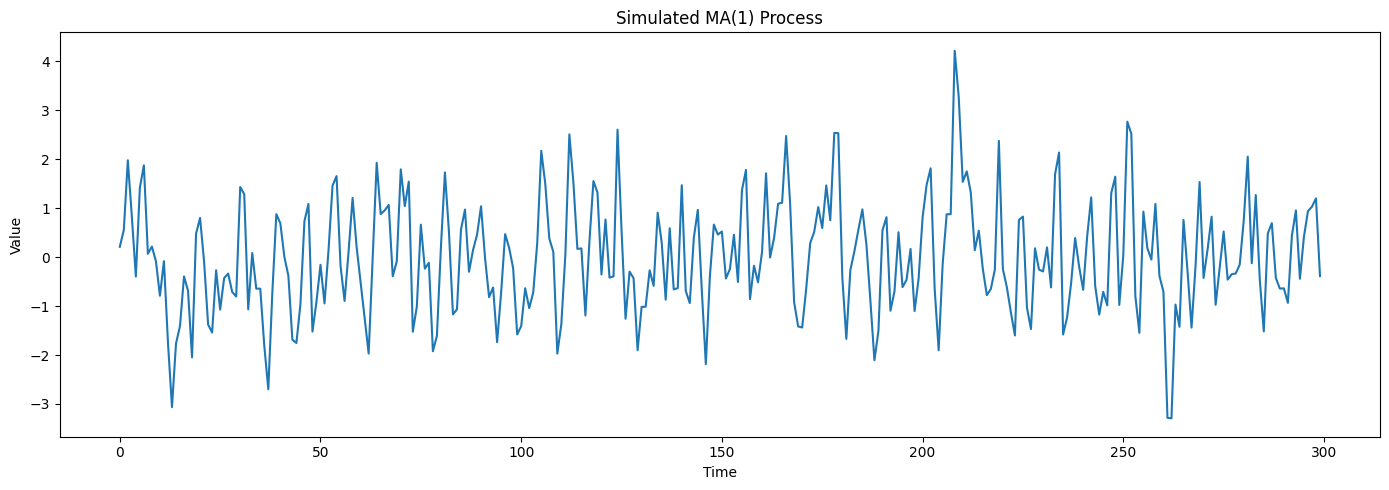

In [46]:
plt.figure(figsize=(14, 5))

plt.plot(ma1_series)

plt.title("Simulated MA(1) Process")
plt.xlabel("Time")
plt.ylabel("Value")

plt.tight_layout()
plt.show()

<Figure size 1200x500 with 0 Axes>

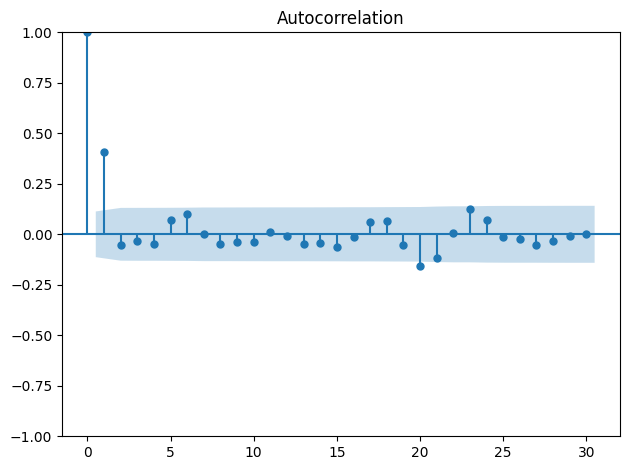

In [47]:
plt.figure(figsize=(12, 5))

plot_acf(
    ma1_series,
    lags=30
)

plt.tight_layout()
plt.show()

<Figure size 1200x500 with 0 Axes>

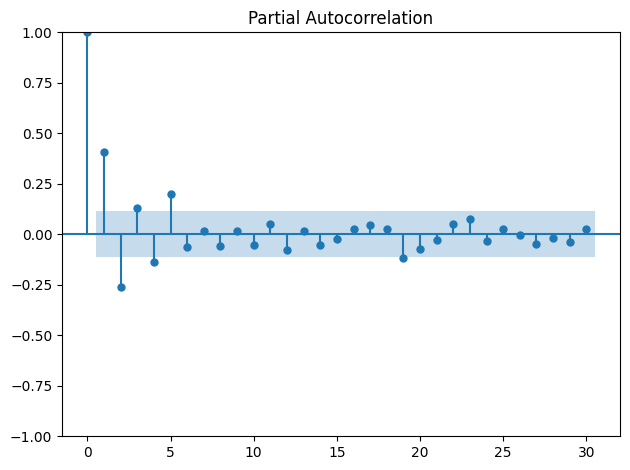

In [48]:
plt.figure(figsize=(12, 5))

plot_pacf(
    ma1_series,
    lags=30,
    method="ywm"
)

plt.tight_layout()
plt.show()

### MA(1) ACF/PACF Pattern

For an MA($q$) process:

- ACF tends to cut off after lag $q$
- PACF tends to decay gradually

For MA(1):

$$
\text{ACF} \rightarrow \text{significant lag 1}
$$

followed by approximately insignificant autocorrelations.

This is roughly the opposite of the typical AR identification pattern.

# 43. AR vs MA

| Property | AR($p$) | MA($q$) |
|---|---|---|
| Uses | Past observations | Past errors |
| Main parameter | $p$ | $q$ |
| Typical ACF | Gradual decay | Cutoff |
| Typical PACF | Cutoff | Gradual decay |
| Memory | Through previous values | Through previous shocks |

### AR intuition

$$
Y_t
\leftarrow
Y_{t-1},Y_{t-2},\ldots
$$

### MA intuition

$$
Y_t
\leftarrow
\epsilon_t,\epsilon_{t-1},\ldots
$$

These models can also be combined.

# 44. ARMA Models

ARMA combines:

- Autoregressive behavior
- Moving-average behavior

An ARMA($p,q$) model is:

$$
Y_t =
c+
\sum_{i=1}^{p}\phi_iY_{t-i}
+
\epsilon_t
+
\sum_{j=1}^{q}\theta_j\epsilon_{t-j}
$$

The model therefore captures both:

$$
\boxed{
\text{Past observations}
+
\text{Past shocks}
}
$$

### Example

ARMA(1,1):

$$
Y_t =
c+
\phi Y_{t-1}
+
\epsilon_t
+
\theta\epsilon_{t-1}
$$

ARMA models are designed for stationary series.

If the original series is non-stationary, differencing may be required first.

In [49]:
from statsmodels.tsa.arima_process import ArmaProcess

np.random.seed(42)

ar = np.array([1, -0.7])
ma = np.array([1, 0.4])

arma_process = ArmaProcess(
    ar,
    ma
)

arma_series = pd.Series(
    arma_process.generate_sample(
        nsample=300
    )
)

arma_series.head()

0    0.496714
1    0.408121
2    0.878068
3    2.396753
4    2.052785
dtype: float64

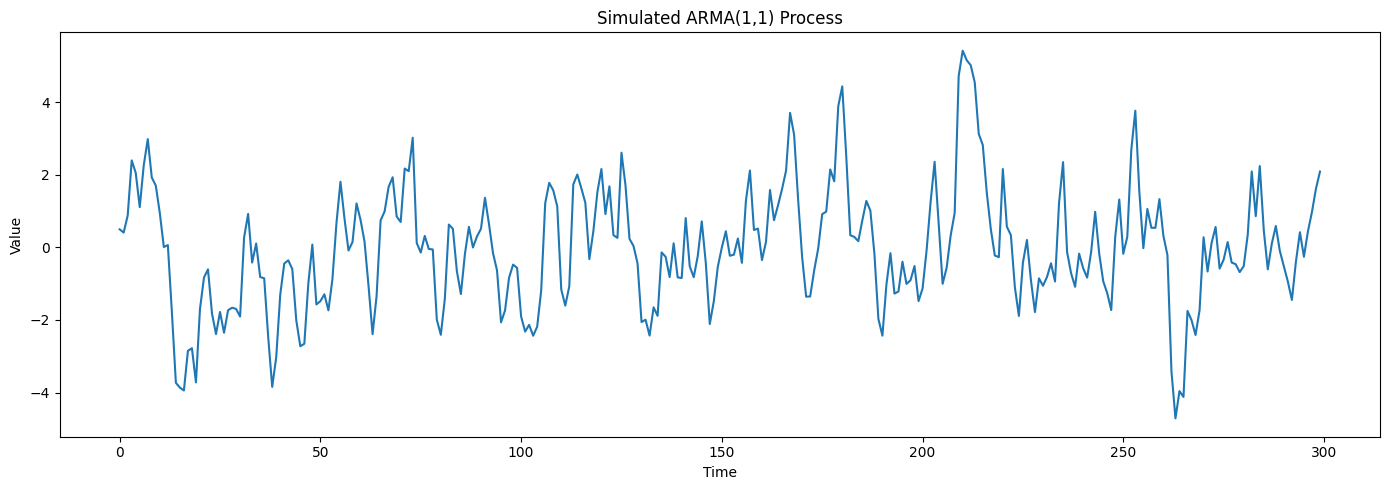

In [50]:
plt.figure(figsize=(14, 5))

plt.plot(arma_series)

plt.title("Simulated ARMA(1,1) Process")
plt.xlabel("Time")
plt.ylabel("Value")

plt.tight_layout()
plt.show()

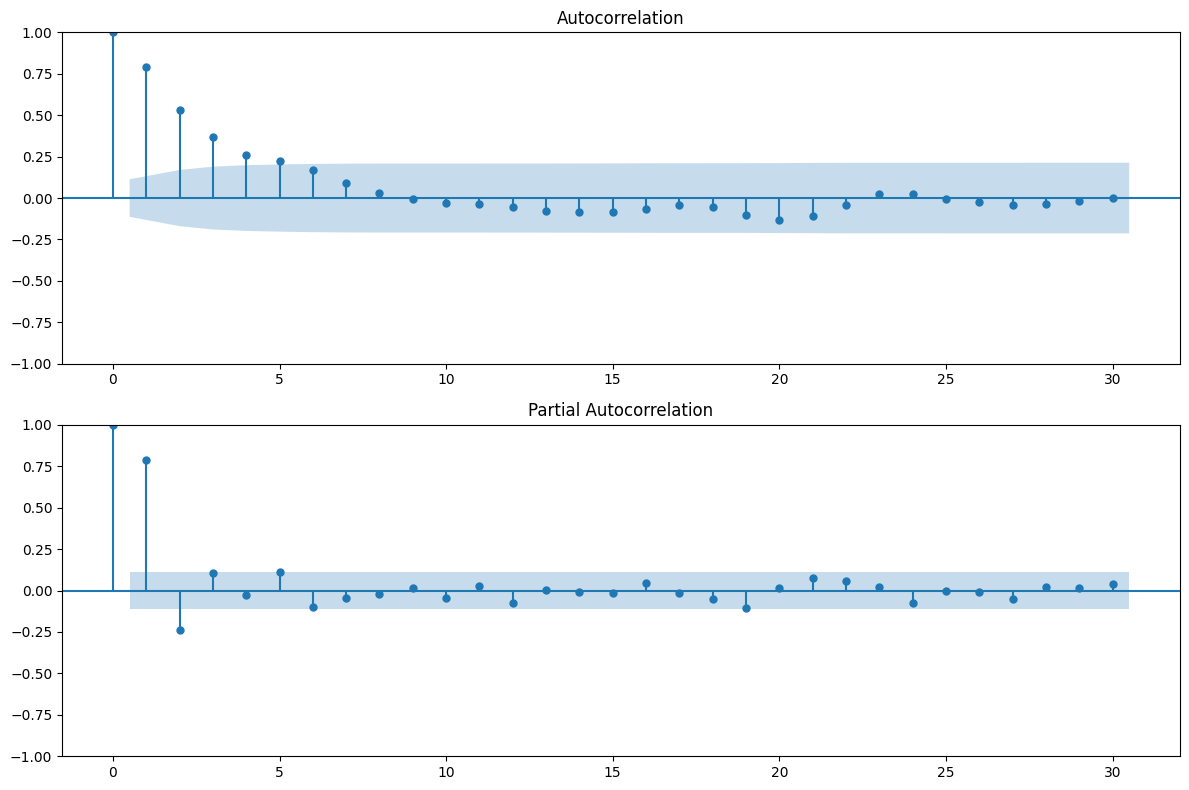

In [52]:
fig = plt.figure(figsize=(12, 8))

ax1 = fig.add_subplot(211)
plot_acf(
    arma_series,
    lags=30,
    ax=ax1
)

ax2 = fig.add_subplot(212)
plot_pacf(
    arma_series,
    lags=30,
    method="ywm",
    ax=ax2
)

plt.tight_layout()
plt.show()

# 45. ARMA Model Identification

A simplified identification strategy is:

### ACF cuts off, PACF decays

Potentially:

$$
MA(q)
$$

### PACF cuts off, ACF decays

Potentially:

$$
AR(p)
$$

### Both decay

Potentially:

$$
ARMA(p,q)
$$

But these patterns are not always perfectly clean.

In real applications, candidate models should be compared using:

- AIC
- BIC
- Validation error
- Residual diagnostics
- Forecast performance
- Domain knowledge

Therefore:

$$
\boxed{
\text{ACF/PACF}
\rightarrow
\text{Candidate Models}
\rightarrow
\text{Validation}
}
$$

# 46. ARIMA

ARIMA stands for:

$$
\boxed{
ARIMA =
AutoRegressive +
Integrated +
Moving Average
}
$$

ARIMA is written as:

$$
ARIMA(p,d,q)
$$

where:

- $p$ = autoregressive order
- $d$ = number of differences
- $q$ = moving-average order

The three components have different roles.

### AR component

Models dependence on previous observations.

### I component

Makes the series approximately stationary through differencing.

### MA component

Models dependence on previous error terms.

# 47. The "Integrated" Component

The term "Integrated" in ARIMA does not mean integration in the usual calculus sense.

It refers to differencing.

If:

$$
d=0
$$

then no differencing is applied.

The model is:

$$
ARIMA(p,0,q)
$$

which is essentially an ARMA model.

If:

$$
d=1
$$

we model the first difference:

$$
\Delta Y_t=Y_t-Y_{t-1}
$$

If:

$$
d=2
$$

we model:

$$
\Delta^2Y_t
$$

Therefore:

$$
ARIMA(p,d,q)
$$

can be viewed conceptually as:

$$
\boxed{
\text{Difference}
\rightarrow
\text{ARMA Model}
\rightarrow
\text{Forecast}
}
$$

# 48. ARIMA on a Non-Stationary Series

We will use the previously generated random walk.

Recall:

$$
Y_t=Y_{t-1}+\epsilon_t
$$

This series is non-stationary.

Therefore, first-order differencing is a natural starting point:

$$
\Delta Y_t=Y_t-Y_{t-1}
$$

We can then fit an ARIMA model to the original series with:

$$
d=1
$$

In [54]:
from statsmodels.tsa.arima.model import ARIMA

random_walk_series = stationarity_df["random_walk"]

arima_model = ARIMA(
    random_walk_series,
    order=(1, 1, 0)
)

arima_result = arima_model.fit()

print(arima_result.summary())

                               SARIMAX Results                                
Dep. Variable:            random_walk   No. Observations:                  300
Model:                 ARIMA(1, 1, 0)   Log Likelihood                -411.699
Date:                Fri, 11 Sep 2026   AIC                            827.398
Time:                        01:54:34   BIC                            834.799
Sample:                    01-01-2025   HQIC                           830.360
                         - 10-27-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0614      0.058      1.053      0.292      -0.053       0.176
sigma2         0.9194      0.077     11.911      0.000       0.768       1.071
Ljung-Box (L1) (Q):                   0.00   Jarque-

# 49. Understanding the ARIMA Order

For:

```python
order=(1, 1, 0)

we have:

$$ p=1 $$ $$ d=1 $$ $$ q=0 $$

Therefore:

$$ ARIMA(1,1,0) $$

means:

Difference the series once
Fit an AR(1) model to the differenced series
Forecast the original series

In [55]:
forecast_steps = 30

forecast = arima_result.forecast(
    steps=forecast_steps
)

forecast.head()

2025-10-28   -6.423843
2025-10-29   -6.422423
2025-10-30   -6.422335
2025-10-31   -6.422330
2025-11-01   -6.422330
Freq: D, Name: predicted_mean, dtype: float64

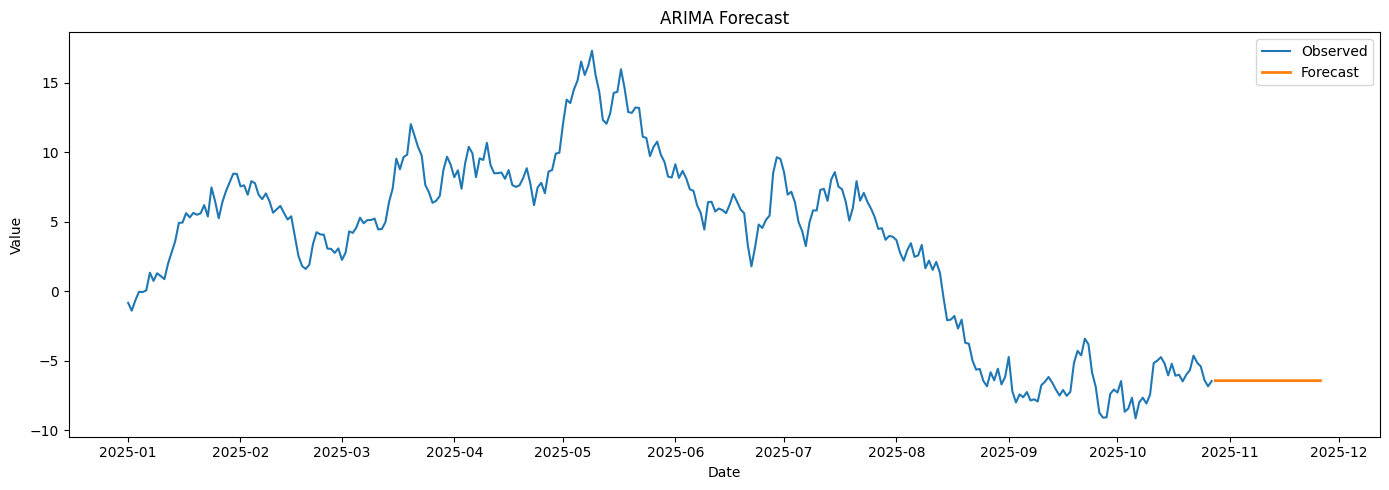

In [56]:
plt.figure(figsize=(14, 5))

plt.plot(
    random_walk_series,
    label="Observed"
)

plt.plot(
    forecast.index,
    forecast,
    label="Forecast",
    linewidth=2
)

plt.title("ARIMA Forecast")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()

plt.tight_layout()
plt.show()

# 50. In-Sample Prediction vs Future Forecast

These are different tasks.

### In-Sample Prediction

Predict observations that are already inside the training period.

### Out-of-Sample Forecast

Predict genuinely future observations that were not available during training.

For example:

```text
Timeline
────────────────────────────────────────>

Training                Test / Future
███████████████████████ | ░░░░░░░░░░░░
                        ↑
                     Forecast


---


# 51. Chronological Train/Test Split

Time-series data must generally be split chronologically.

For example:

$$
\text{Past}
\rightarrow
\text{Training}
$$

$$
\text{Future}
\rightarrow
\text{Testing}
$$

Never randomly shuffle the observations when evaluating a forecasting model.

Example:

```text
Training                  Test
███████████████████████   ░░░░░░░░░░

The model only receives information from the past.

This simulates the real forecasting situation.

In [57]:
split_point = int(
    len(random_walk_series) * 0.8
)

train = random_walk_series.iloc[:split_point]
test = random_walk_series.iloc[split_point:]

print("Training observations:", len(train))
print("Testing observations:", len(test))

Training observations: 240
Testing observations: 60


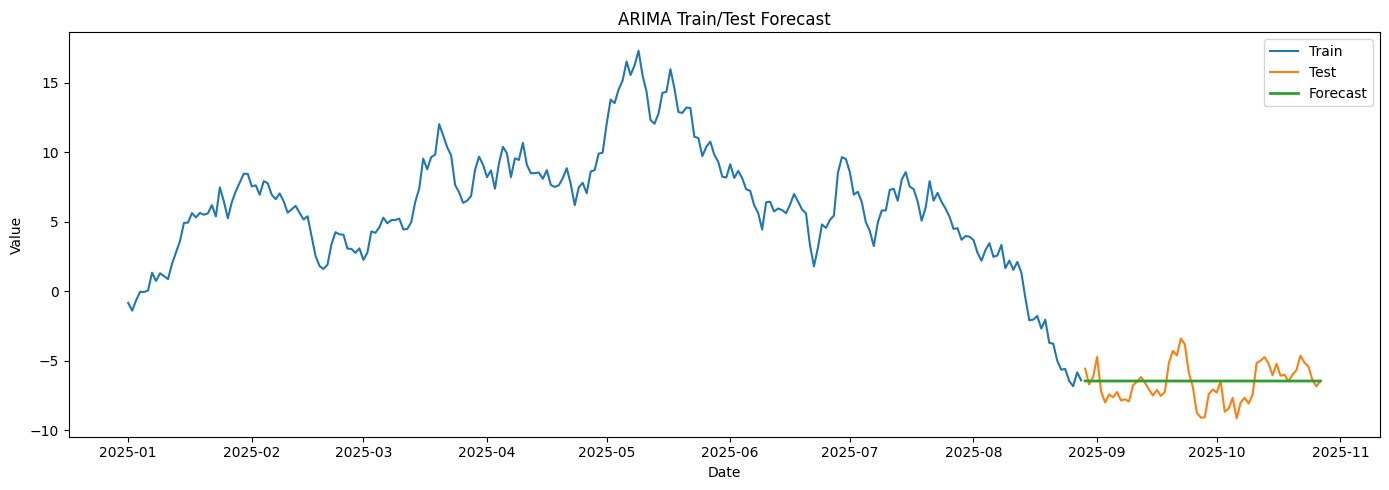

In [58]:
arima_model = ARIMA(
    train,
    order=(1, 1, 0)
)

arima_result = arima_model.fit()

forecast = arima_result.forecast(
    steps=len(test)
)

plt.figure(figsize=(14, 5))

plt.plot(
    train,
    label="Train"
)

plt.plot(
    test,
    label="Test"
)

plt.plot(
    test.index,
    forecast,
    label="Forecast",
    linewidth=2
)

plt.title("ARIMA Train/Test Forecast")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()

plt.tight_layout()
plt.show()

# 52. Forecast Evaluation

A forecasting model should be evaluated on observations that were not used during training.

Common metrics include:

### Mean Absolute Error

$$
MAE =
\frac{1}{n}
\sum_{t=1}^{n}
|y_t-\hat{y}_t|
$$

MAE is easy to interpret because it is expressed in the same units as the target.

---

### Mean Squared Error

$$
MSE =
\frac{1}{n}
\sum_{t=1}^{n}
(y_t-\hat{y}_t)^2
$$

MSE penalizes large errors more strongly.

---

### Root Mean Squared Error

$$
RMSE =
\sqrt{
\frac{1}{n}
\sum_{t=1}^{n}
(y_t-\hat{y}_t)^2
}
$$

RMSE is expressed in the original target units.

Lower values are generally better.

In [59]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

mae = mean_absolute_error(
    test,
    forecast
)

rmse = np.sqrt(
    mean_squared_error(
        test,
        forecast
    )
)

print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

MAE:  1.1145
RMSE: 1.3492


# 53. ARIMA Residual Diagnostics

After fitting a model, we should inspect its residuals.

Residuals are:

$$
e_t = y_t-\hat{y}_t
$$

A good model should leave residuals that contain little predictable temporal structure.

We want residuals to approximately behave like:

$$
WN(0,\sigma^2)
$$

That means:

- Mean approximately zero
- Stable variance
- Little autocorrelation
- No obvious remaining structure

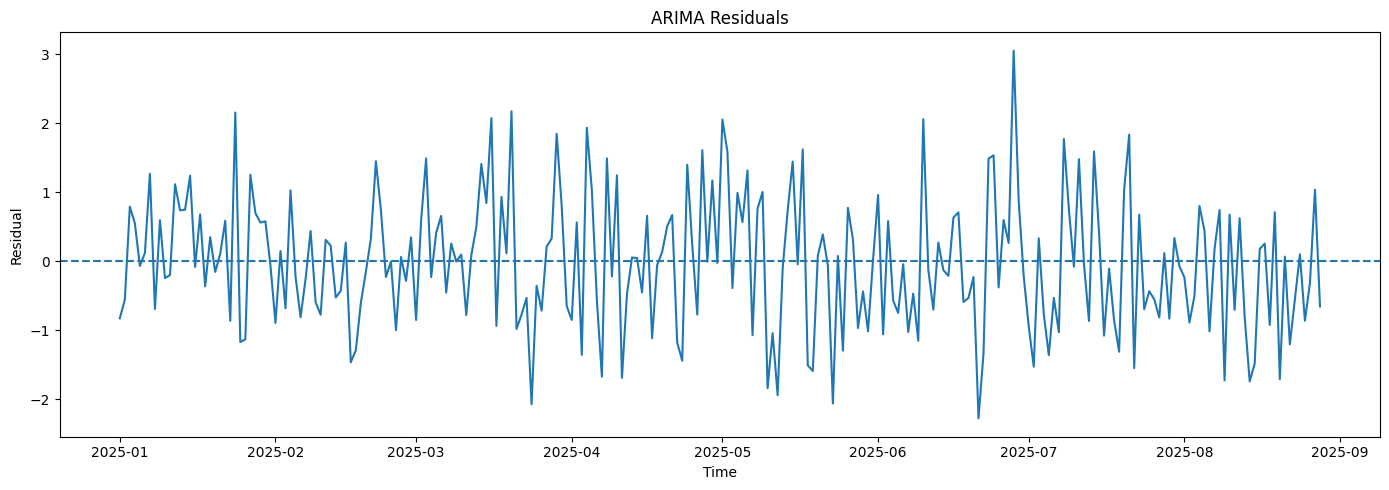

In [60]:
residuals = arima_result.resid

plt.figure(figsize=(14, 5))

plt.plot(residuals)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("ARIMA Residuals")
plt.xlabel("Time")
plt.ylabel("Residual")

plt.tight_layout()
plt.show()

<Figure size 1200x500 with 0 Axes>

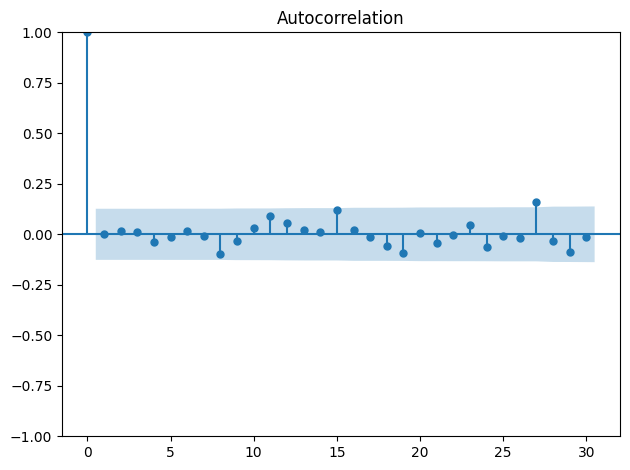

In [61]:
plt.figure(figsize=(12, 5))

plot_acf(
    residuals.dropna(),
    lags=30
)

plt.tight_layout()
plt.show()

In [62]:
ljung_box = acorr_ljungbox(
    residuals.dropna(),
    lags=[10, 20],
    return_df=True
)

ljung_box

,lb_stat,lb_pvalue
10,3.311245,0.973122
20,13.269722,0.865514


# 54. Interpreting Residual Diagnostics

Suppose the Ljung-Box test gives:

$$
p > 0.05
$$

Then we fail to reject the null hypothesis of no autocorrelation at the tested lags.

This is generally desirable for model residuals.

If instead:

$$
p < 0.05
$$

there is evidence of remaining autocorrelation.

This suggests that the model may have failed to capture some temporal structure.

Possible causes include:

- Incorrect AR order
- Incorrect MA order
- Missing seasonality
- Structural changes
- Incorrect differencing
- Missing external variables

# 55. AIC and BIC

When comparing statistical models, we often want to balance:

$$
\text{Model Fit}
$$

against:

$$
\text{Model Complexity}
$$

Two commonly used criteria are:

### Akaike Information Criterion

$$
AIC =
2k-2\ln(\hat{L})
$$

### Bayesian Information Criterion

$$
BIC =
k\ln(n)-2\ln(\hat{L})
$$

where:

- $k$ = number of estimated parameters
- $n$ = number of observations
- $\hat{L}$ = maximized likelihood

Lower values are preferred when comparing models fitted to the same dataset.

However:

> The lowest AIC/BIC model is not automatically the best forecasting model.

Out-of-sample forecast performance still matters.

In [63]:
print("AIC:", arima_result.aic)
print("BIC:", arima_result.bic)

AIC: 662.6200344188196
BIC: 669.5729615226826


## 56. Comparing Candidate ARIMA Models

In [64]:
candidate_orders = [
    (0, 1, 0),
    (1, 1, 0),
    (0, 1, 1),
    (1, 1, 1),
    (2, 1, 0),
    (0, 1, 2),
    (2, 1, 1)
]

results = []

for order in candidate_orders:
    model = ARIMA(
        train,
        order=order
    )

    result = model.fit()

    results.append(
        {
            "order": order,
            "AIC": result.aic,
            "BIC": result.bic
        }
    )

comparison = pd.DataFrame(results)

comparison.sort_values("AIC")

,order,AIC,BIC
0,"(0, 1, 0)",662.145960,665.622424
1,"(1, 1, 0)",662.620034,669.572962
2,"(0, 1, 1)",662.681401,669.634328
4,"(2, 1, 0)",664.535576,674.964967
3,"(1, 1, 1)",664.540565,674.969956
5,"(0, 1, 2)",664.547710,674.977101
6,"(2, 1, 1)",666.532878,680.438733


# 57. Important ARIMA Model Selection Principle

Do not select an ARIMA model using only one criterion.

A robust workflow is:

$$
\boxed{
\text{Theory}
+
\text{ACF/PACF}
+
\text{AIC/BIC}
+
\text{Residual Diagnostics}
+
\text{Out-of-Sample Performance}
}
$$

For example:

```text
Stationarity
     ↓
Determine d
     ↓
ACF / PACF
     ↓
Candidate p, q
     ↓
Fit several models
     ↓
AIC / BIC
     ↓
Residual Diagnostics
     ↓
Time-Series Validation
     ↓
Final Model


---


# 58. Limitations of ARIMA

ARIMA is powerful, but it has important limitations.

### 1. Linear Relationships

ARIMA primarily models linear temporal relationships.

### 2. Requires Appropriate Differencing

Poor choice of $d$ can result in:

- Under-differencing
- Over-differencing

### 3. Seasonality

Basic ARIMA does not explicitly model seasonal structure.

For strong seasonality, SARIMA is usually more appropriate.

### 4. Structural Changes

ARIMA can struggle when the underlying data-generating process changes.

### 5. External Variables

ARIMA does not automatically incorporate external predictors.

Extensions such as ARIMAX/SARIMAX can incorporate exogenous variables.

### 6. Long-Term Complex Patterns

Highly nonlinear or very complex temporal relationships may require other approaches such as:

- Tree-based ML
- State-space models
- Neural networks
- Transformers

# 59. Classical Time-Series Models — Summary

| Model | Main Idea |
|---|---|
| AR($p$) | Uses previous observations |
| MA($q$) | Uses previous errors |
| ARMA($p,q$) | AR + MA |
| ARIMA($p,d,q$) | ARMA + differencing |
| SARIMA | ARIMA + seasonality |

### AR

$$
Y_t=f(Y_{t-1},Y_{t-2},\ldots)+\epsilon_t
$$

### MA

$$
Y_t=f(\epsilon_{t-1},\epsilon_{t-2},\ldots)+\epsilon_t
$$

### ARIMA

$$
ARIMA(p,d,q)
$$

### SARIMA

$$
SARIMA(p,d,q)(P,D,Q,m)
$$

# 60. Seasonal Time Series

Many real-world time series contain repeating patterns.

Examples:

- Daily electricity demand → hourly/daily patterns
- Retail sales → yearly patterns
- Website traffic → weekly patterns
- Temperature → yearly seasonal patterns

A seasonal period is represented by:

$$
m
$$

where $m$ is the number of observations in one complete seasonal cycle.

Examples:

| Frequency | Typical Seasonal Period |
|---|---:|
| Hourly | 24 |
| Daily | 7 |
| Weekly | 52 |
| Monthly | 12 |
| Quarterly | 4 |

Seasonality should be identified from the data rather than assumed automatically.

# 61. Seasonal Differencing

Ordinary differencing compares an observation with the immediately previous observation:

$$
\Delta Y_t = Y_t-Y_{t-1}
$$

Seasonal differencing compares an observation with the observation from one complete seasonal cycle earlier:

$$
\Delta_mY_t=Y_t-Y_{t-m}
$$

where $m$ is the seasonal period.

For daily data with weekly seasonality:

$$
m=7
$$

so:

$$
\Delta_7Y_t=Y_t-Y_{t-7}
$$

Seasonal differencing can remove repeating seasonal patterns.

### Example

Suppose monthly sales have yearly seasonality:

$$
m=12
$$

Then:

$$
\Delta_{12}Y_t=Y_t-Y_{t-12}
$$

compares this month's sales with the same month last year.

In [65]:
seasonal_diff = (
    df["value"]
    .diff(7)
)

seasonal_diff.head(10)

date
2025-01-01         NaN
2025-01-02         NaN
2025-01-03         NaN
2025-01-04         NaN
2025-01-05         NaN
2025-01-06         NaN
2025-01-07         NaN
2025-01-08    1.773700
2025-01-09   -0.032092
2025-01-10    0.646153
Name: value, dtype: float64

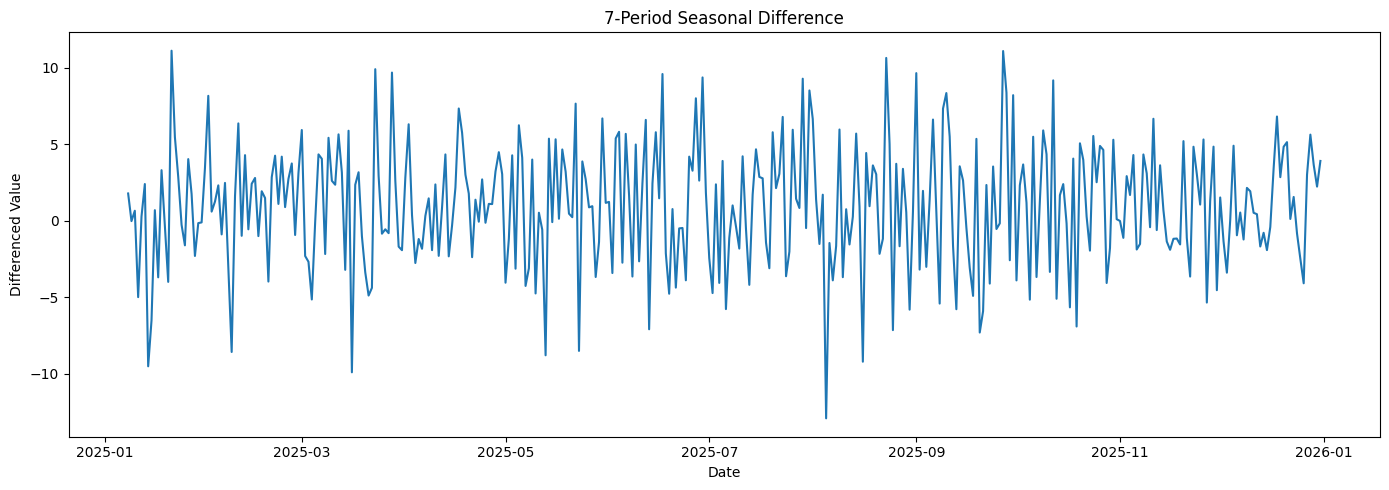

In [66]:
plt.figure(figsize=(14, 5))

plt.plot(
    seasonal_diff
)

plt.title("7-Period Seasonal Difference")
plt.xlabel("Date")
plt.ylabel("Differenced Value")

plt.tight_layout()
plt.show()

# 62. Seasonal Decomposition

Decomposition separates a time series into interpretable components.

For an additive model:

$$
Y_t=T_t+S_t+R_t
$$

where:

- $T_t$ = trend
- $S_t$ = seasonal component
- $R_t$ = residual

For a multiplicative model:

$$
Y_t=T_t\times S_t\times R_t
$$

Decomposition helps us understand whether the observed behavior is primarily caused by:

- Trend
- Seasonality
- Irregular variation

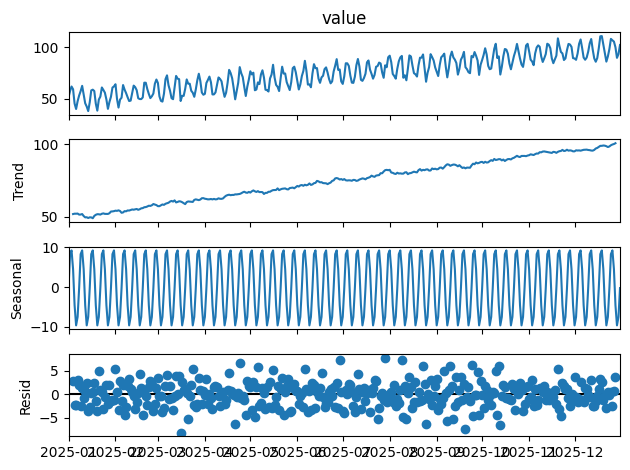

In [67]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    df["value"],
    model="additive",
    period=7
)

decomposition.plot()

plt.tight_layout()
plt.show()

# 63. STL Decomposition

STL stands for:

$$
\text{Seasonal-Trend decomposition using Loess}
$$

STL uses locally estimated regression to separate:

- Trend
- Seasonal component
- Residual

STL is often more flexible than classical decomposition.

It can handle changing trend behavior better and is generally a strong exploratory tool.

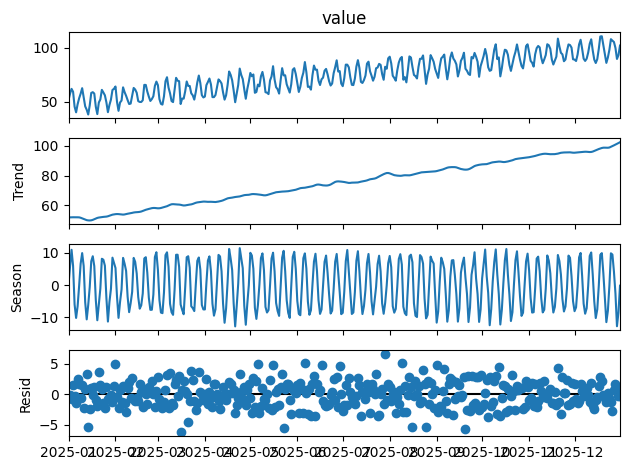

In [68]:
from statsmodels.tsa.seasonal import STL

stl = STL(
    df["value"],
    period=7
)

stl_result = stl.fit()

stl_result.plot()

plt.tight_layout()
plt.show()

# 64. Seasonal ARIMA — SARIMA

SARIMA extends ARIMA to explicitly model seasonal behavior.

The model is written as:

$$
SARIMA(p,d,q)(P,D,Q,m)
$$

where:

### Non-seasonal parameters

$$
p = \text{AR order}
$$

$$
d = \text{non-seasonal differencing}
$$

$$
q = \text{MA order}
$$

### Seasonal parameters

$$
P = \text{seasonal AR order}
$$

$$
D = \text{seasonal differencing order}
$$

$$
Q = \text{seasonal MA order}
$$

$$
m = \text{seasonal period}
$$

Therefore:

$$
SARIMA(p,d,q)(P,D,Q,m)
$$

can model both short-term temporal dependence and repeating seasonal behavior.

# 65. SARIMA Intuition

Suppose we have daily data with weekly seasonality.

Then:

$$
m=7
$$

A model such as:

$$
SARIMA(1,1,1)(1,1,1,7)
$$

contains:

- One non-seasonal AR term
- One non-seasonal difference
- One non-seasonal MA term
- One seasonal AR term
- One seasonal difference
- One seasonal MA term
- Weekly seasonality

Conceptually:

$$
\boxed{
\text{Short-Term Dynamics}
+
\text{Seasonal Dynamics}
}
$$

## 66. SARIMA Example

In [69]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    df["value"],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit(
    disp=False
)

print(sarima_result.summary())

c:\Users\soumy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\soumy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                     
Dep. Variable:                             value   No. Observations:                  365
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood                -873.301
Date:                           Fri, 11 Sep 2026   AIC                           1756.603
Time:                                   02:06:54   BIC                           1775.864
Sample:                               01-01-2025   HQIC                          1764.271
                                    - 12-31-2025                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0604      0.061     -0.998      0.318      -0.179       0.058
ma.L1         -1.0000     50.600     -0.020

In [70]:
sarima_forecast = sarima_result.forecast(
    steps=30
)

sarima_forecast.head()

2026-01-01    108.640724
2026-01-02    109.917392
2026-01-03    105.283387
2026-01-04     96.373318
2026-01-05     91.383394
Freq: D, Name: predicted_mean, dtype: float64

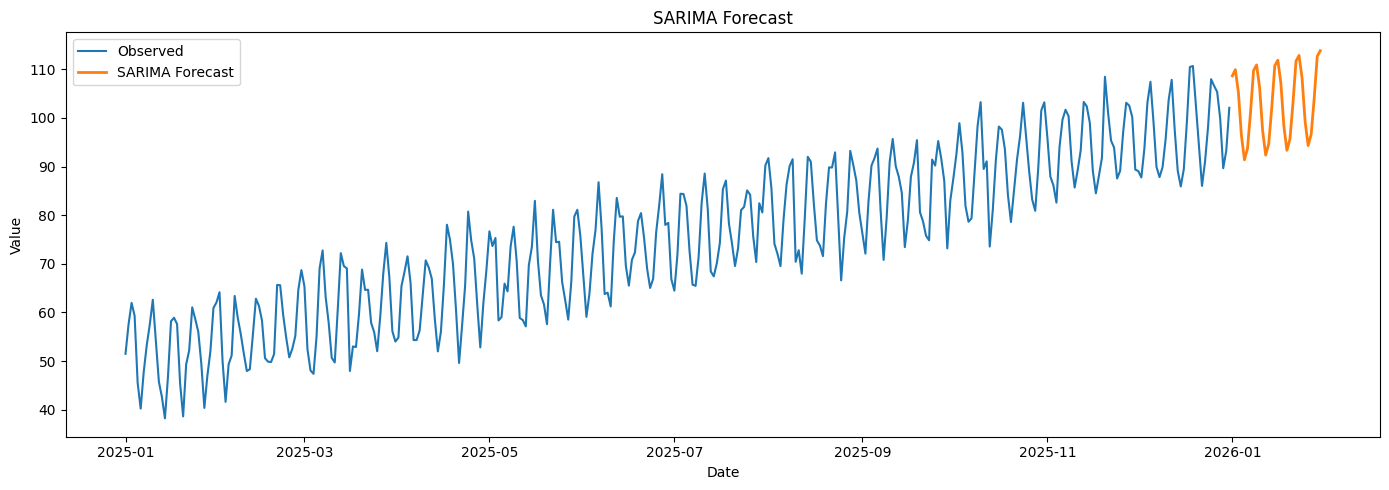

In [71]:
plt.figure(figsize=(14, 5))

plt.plot(
    df["value"],
    label="Observed"
)

plt.plot(
    sarima_forecast.index,
    sarima_forecast,
    label="SARIMA Forecast",
    linewidth=2
)

plt.title("SARIMA Forecast")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()

plt.tight_layout()
plt.show()

# 67. SARIMAX

SARIMAX extends SARIMA by allowing external explanatory variables.

The X represents:

$$
\text{Exogenous Variables}
$$

Examples:

- Temperature
- Advertising expenditure
- Holiday indicators
- Interest rates
- Promotions
- Weather conditions
- Economic indicators

A conceptual representation is:

$$
Y_t =
\text{SARIMA Dynamics}
+
\beta X_t
+
\epsilon_t
$$

This is useful when the target depends not only on its own historical values but also on external information.

# 68. Example of Exogenous Variables

Suppose we want to forecast electricity demand.

The target is:

$$
Y_t=\text{Electricity Demand}
$$

External variables could include:

$$
X_t=
\begin{bmatrix}
\text{Temperature}\\
\text{Humidity}\\
\text{Holiday}\\
\text{Working Day}
\end{bmatrix}
$$

Then a SARIMAX model can use both:

$$
Y_{t-1},Y_{t-2},\ldots
$$

and:

$$
X_t
$$

to produce forecasts.

The important requirement is:

> Future values of the exogenous variables must be known or separately forecasted at prediction time.

# 69. Forecasting Baselines

Before building sophisticated models, we should establish simple baselines.

A model is useful only if it improves upon a reasonable baseline.

Common forecasting baselines include:

1. Mean forecast
2. Naive forecast
3. Seasonal naive forecast
4. Drift forecast

These models are simple but extremely important.

# 70. Mean Forecast

The mean forecast predicts every future observation using the historical mean.

$$
\hat{Y}_{T+h}
=
\frac{1}{T}
\sum_{t=1}^{T}Y_t
$$

This is a very simple baseline.

It can work reasonably well when there is little trend or seasonality.

However, it performs poorly when the series has strong temporal structure.

In [72]:
mean_forecast = np.repeat(
    train.mean(),
    len(test)
)

mean_forecast = pd.Series(
    mean_forecast,
    index=test.index
)

mean_forecast.head()

2025-08-29    6.154518
2025-08-30    6.154518
2025-08-31    6.154518
2025-09-01    6.154518
2025-09-02    6.154518
Freq: D, dtype: float64

# 71. Naive Forecast

The naive method assumes that the most recent observation is the best prediction of the future.

$$
\hat{Y}_{T+h}=Y_T
$$

for every forecast horizon $h$.

In simple terms:

```text
Tomorrow = Today
Next week = Today
Next month = Today

In [73]:
naive_forecast = pd.Series(
    train.iloc[-1],
    index=test.index
)

naive_forecast.head()

2025-08-29   -6.396904
2025-08-30   -6.396904
2025-08-31   -6.396904
2025-09-01   -6.396904
2025-09-02   -6.396904
Freq: D, dtype: float64

# 72. Seasonal Naive Forecast

When strong seasonality exists, a seasonal naive model can be much better than a normal naive model.

The forecast repeats the value from the previous seasonal cycle:

$$
\hat{Y}_{T+h}
=
Y_{T+h-m}
$$

where:

$$
m=\text{seasonal period}
$$

For daily data with weekly seasonality:

$$
m=7
$$

Therefore:

```text
Monday forecast = previous Monday
Tuesday forecast = previous Tuesday
...

In [74]:
seasonal_period = 7

seasonal_naive_values = []

for i in range(len(test)):
    value = train.iloc[
        -seasonal_period + (i % seasonal_period)
    ]
    
    seasonal_naive_values.append(value)

seasonal_naive_forecast = pd.Series(
    seasonal_naive_values,
    index=test.index
)

seasonal_naive_forecast.head(10)

2025-08-29   -4.976899
2025-08-30   -5.628735
2025-08-31   -5.581336
2025-09-01   -6.441749
2025-09-02   -6.826305
2025-09-03   -5.820012
2025-09-04   -6.396904
2025-09-05   -4.976899
2025-09-06   -5.628735
2025-09-07   -5.581336
Freq: D, dtype: float64

# 73. Drift Forecast

The drift method assumes that the historical trend continues into the future.

A simple drift forecast is:

$$
\hat{Y}_{T+h}
=
Y_T+
h
\left(
\frac{Y_T-Y_1}{T-1}
\right)
$$

The estimated average change per time step is:

$$
\text{Drift}
=
\frac{Y_T-Y_1}{T-1}
$$

This is useful when a series has a relatively stable long-term trend.

In [75]:
y1 = train.iloc[0]
yT = train.iloc[-1]

drift = (
    yT - y1
) / (
    len(train) - 1
)

drift_forecast = pd.Series(
    [
        yT + h * drift
        for h in range(1, len(test) + 1)
    ],
    index=test.index
)

drift_forecast.head()

2025-08-29   -6.420201
2025-08-30   -6.443497
2025-08-31   -6.466794
2025-09-01   -6.490091
2025-09-02   -6.513388
Freq: D, dtype: float64

## 74. Comparing Baselines

In [76]:
baseline_results = []

forecasts = {
    "Mean": mean_forecast,
    "Naive": naive_forecast,
    "Seasonal Naive": seasonal_naive_forecast,
    "Drift": drift_forecast
}

for name, prediction in forecasts.items():
    mae = mean_absolute_error(
        test,
        prediction
    )

    rmse = np.sqrt(
        mean_squared_error(
            test,
            prediction
        )
    )

    baseline_results.append(
        {
            "Model": name,
            "MAE": mae,
            "RMSE": rmse
        }
    )

baseline_comparison = pd.DataFrame(
    baseline_results
)

baseline_comparison.sort_values(
    "RMSE"
)

,Model,MAE,RMSE
1,Naive,1.124549,1.356256
3,Drift,1.263909,1.548591
2,Seasonal Naive,1.338448,1.652452
0,Mean,12.766714,12.836746


## 75. Plotting Baseline Forecasts

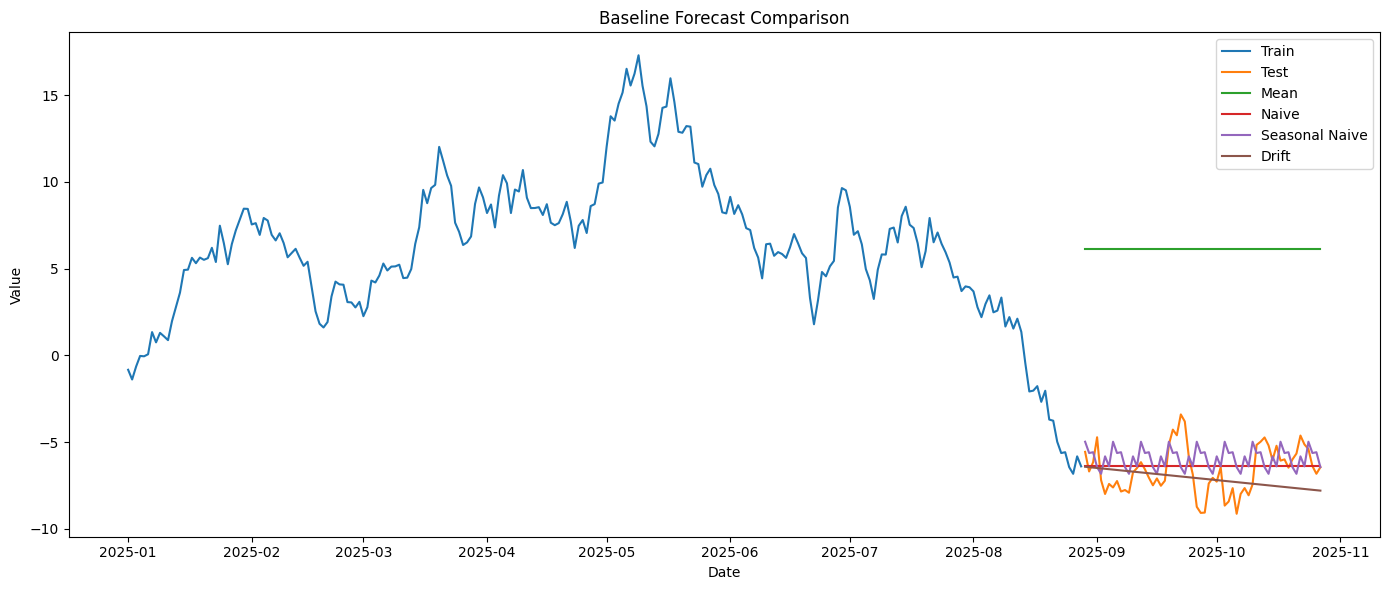

In [77]:
plt.figure(figsize=(14, 6))

plt.plot(
    train,
    label="Train"
)

plt.plot(
    test,
    label="Test"
)

for name, prediction in forecasts.items():
    plt.plot(
        prediction,
        label=name
    )

plt.title("Baseline Forecast Comparison")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()

plt.tight_layout()
plt.show()

# 76. Exponential Smoothing

Exponential smoothing methods assign greater weight to recent observations.

The basic idea is:

$$
\text{Recent observations}
>
\text{Older observations}
$$

This makes exponential smoothing particularly useful when recent observations contain more relevant information about the near future.

Major methods include:

1. Simple Exponential Smoothing
2. Holt's Method
3. Holt-Winters Method

# 77. Simple Exponential Smoothing

Simple Exponential Smoothing is appropriate when the series has:

- No strong trend
- No strong seasonality

The level is updated using:

$$
\ell_t
=
\alpha Y_t
+
(1-\alpha)\ell_{t-1}
$$

where:

$$
0 < \alpha < 1
$$

The parameter $\alpha$ controls how quickly the model reacts to recent observations.

### Large $\alpha$

More weight on recent observations.

### Small $\alpha$

More smoothing and greater influence from historical observations.

In [79]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

ses_model = SimpleExpSmoothing(
    train,
    initialization_method="estimated"
)

ses_result = ses_model.fit(
    optimized=True
)

ses_forecast = ses_result.forecast(
    len(test)
)

ses_forecast.head()

2025-08-29   -6.396904
2025-08-30   -6.396904
2025-08-31   -6.396904
2025-09-01   -6.396904
2025-09-02   -6.396904
Freq: D, dtype: float64

# 78. Holt's Linear Trend Method

Simple exponential smoothing does not explicitly model trend.

Holt's method extends exponential smoothing by modeling:

1. Level
2. Trend

The level equation can be written as:

$$
\ell_t
=
\alpha Y_t
+
(1-\alpha)(\ell_{t-1}+b_{t-1})
$$

The trend equation is:

$$
b_t
=
\beta^*(\ell_t-\ell_{t-1})
+
(1-\beta^*)b_{t-1}
$$

The forecast is:

$$
\hat{Y}_{t+h}
=
\ell_t+hb_t
$$

Holt's method is appropriate for series with trend but without strong seasonality.

In [80]:
from statsmodels.tsa.holtwinters import Holt

holt_model = Holt(
    train,
    initialization_method="estimated"
)

holt_result = holt_model.fit(
    optimized=True
)

holt_forecast = holt_result.forecast(
    len(test)
)

holt_forecast.head()

2025-08-29   -6.537729
2025-08-30   -6.678553
2025-08-31   -6.819378
2025-09-01   -6.960202
2025-09-02   -7.101027
Freq: D, dtype: float64

# 79. Holt-Winters Exponential Smoothing

Holt-Winters extends Holt's method by explicitly modeling seasonality.

It can model:

- Level
- Trend
- Seasonality

Therefore it is also called:

$$
\boxed{\text{Triple Exponential Smoothing}}
$$

Two common seasonal forms are:

### Additive seasonality

Seasonal variation is approximately constant:

$$
Y_t=T_t+S_t+R_t
$$

### Multiplicative seasonality

Seasonal variation changes with the level:

$$
Y_t=T_t\times S_t\times R_t
$$

The correct choice depends on the behavior of the data.

In [81]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

hw_model = ExponentialSmoothing(
    train,
    trend="add",
    seasonal="add",
    seasonal_periods=7,
    initialization_method="estimated"
)

hw_result = hw_model.fit(
    optimized=True
)

hw_forecast = hw_result.forecast(
    len(test)
)

hw_forecast.head()

2025-08-29   -6.456880
2025-08-30   -6.770014
2025-08-31   -6.940282
2025-09-01   -7.230472
2025-09-02   -7.098733
Freq: D, dtype: float64

## 80. Comparing Exponential Smoothing Models

In [82]:
exp_results = []

exp_forecasts = {
    "Simple Exponential Smoothing": ses_forecast,
    "Holt": holt_forecast,
    "Holt-Winters": hw_forecast
}

for name, prediction in exp_forecasts.items():
    mae = mean_absolute_error(
        test,
        prediction
    )

    rmse = np.sqrt(
        mean_squared_error(
            test,
            prediction
        )
    )

    exp_results.append(
        {
            "Model": name,
            "MAE": mae,
            "RMSE": rmse
        }
    )

exp_comparison = pd.DataFrame(
    exp_results
)

exp_comparison.sort_values(
    "RMSE"
)

,Model,MAE,RMSE
0,Simple Exponential Smoothing,1.124549,1.356256
1,Holt,4.113506,5.057367
2,Holt-Winters,4.369822,5.336192


# 81. Forecast Confidence Intervals

A point forecast gives one estimated future value:

$$
\hat{Y}_{T+h}
$$

But forecasts are uncertain.

Instead of only reporting:

$$
\hat{Y}_{T+h}=120
$$

we can report an interval:

$$
[L_{T+h},U_{T+h}]
$$

For example:

$$
95\%\text{ Prediction Interval}
$$

means that under the model assumptions, the interval is intended to contain the future observation with approximately 95% coverage.

Prediction intervals generally become wider as the forecast horizon increases.

Conceptually:

```text
Forecast Horizon
      →
Uncertainty
      ↑
      │
      │       /------\
      │      /        \
      │-----/ Forecast \-----
      │    /            \
      └──────────────────────

In [83]:
forecast_result = arima_result.get_forecast(
    steps=len(test)
)

forecast_mean = forecast_result.predicted_mean

forecast_ci = forecast_result.conf_int()

forecast_mean.head()

2025-08-29   -6.442915
2025-08-30   -6.446584
2025-08-31   -6.446877
2025-09-01   -6.446900
2025-09-02   -6.446902
Freq: D, Name: predicted_mean, dtype: float64

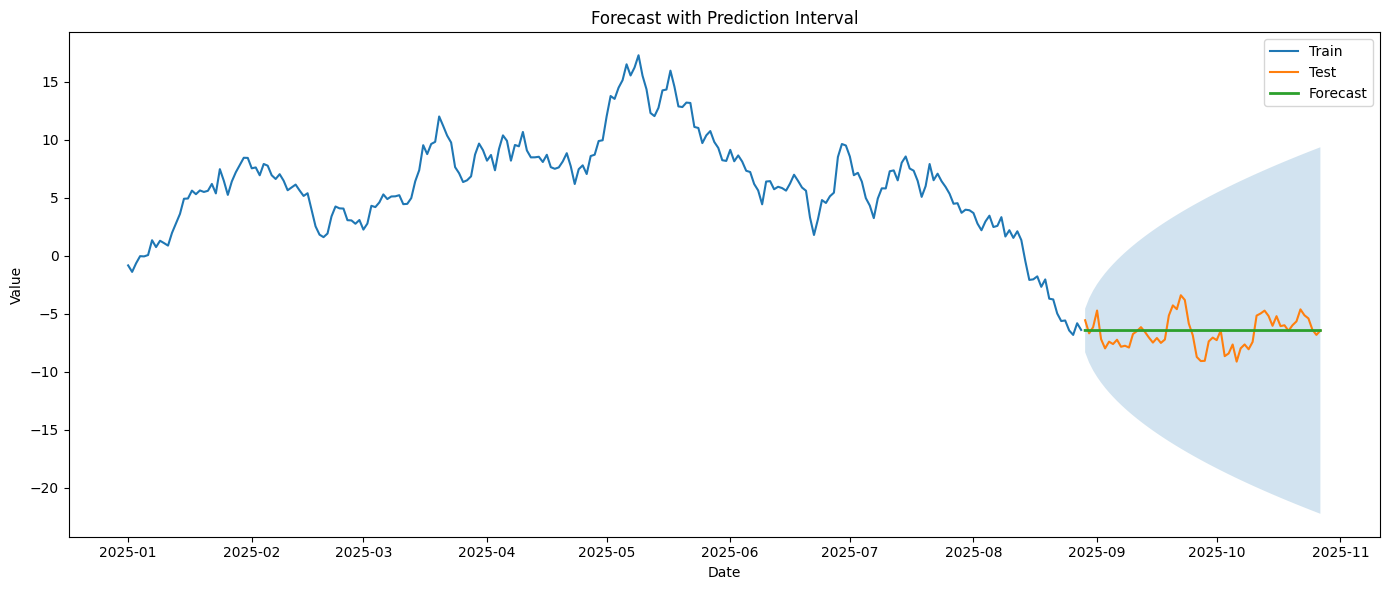

In [84]:
plt.figure(figsize=(14, 6))

plt.plot(
    train,
    label="Train"
)

plt.plot(
    test,
    label="Test"
)

plt.plot(
    forecast_mean,
    label="Forecast",
    linewidth=2
)

plt.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    alpha=0.2
)

plt.title("Forecast with Prediction Interval")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()

plt.tight_layout()
plt.show()

# 82. Choosing a Classical Forecasting Model

There is no universally best forecasting model.

A practical decision process is:

### Mostly stable series

Consider:

$$
\text{Naive / Mean / SES}
$$

### Trend

Consider:

$$
\text{Holt}
$$

### Trend + Seasonality

Consider:

$$
\text{Holt-Winters}
$$

### Autocorrelation without strong seasonality

Consider:

$$
ARIMA
$$

### Strong seasonal autocorrelation

Consider:

$$
SARIMA
$$

### External predictors

Consider:

$$
SARIMAX
$$

The final choice should be based on:

$$
\boxed{
\text{Validation Performance}
+
\text{Residual Diagnostics}
+
\text{Practical Considerations}
}
$$

# 83. Important Warning: Do Not Overfit the Time Series

Increasing model complexity does not guarantee better forecasting.

For example:

$$
ARIMA(5,2,5)
$$

is not automatically better than:

$$
ARIMA(1,1,1)
$$

Similarly, a highly complex seasonal model may fit historical observations extremely well while performing poorly on future data.

The goal is not:

$$
\text{Best Training Fit}
$$

The goal is:

$$
\boxed{
\text{Best Generalization to Future Data}
}
$$

## Current Progress
```
Time Series Fundamentals
        ↓
Components
        ↓
Datetime / Resampling
        ↓
Rolling / Expanding / Lags
        ↓
Stationarity
        ↓
ADF / KPSS
        ↓
Differencing
        ↓
ACF / PACF
        ↓
White Noise
        ↓
Ljung-Box
        ↓
AR
        ↓
MA
        ↓
ARMA
        ↓
ARIMA
        ↓
Seasonal Differencing
        ↓
Decomposition / STL
        ↓
SARIMA
        ↓
SARIMAX
        ↓
Forecasting Baselines
        ↓
Exponential Smoothing
        ↓
Prediction Intervals
        ↓
Model Selection

# 84. Why Ordinary Cross-Validation Does Not Work for Time Series

In ordinary machine learning, we commonly use random cross-validation.

For example:

$$
\text{Dataset}
\rightarrow
\text{Randomly shuffle}
\rightarrow
\text{Train / Validation}
$$

This is usually inappropriate for time series.

Consider:

```text
2019 → 2020 → 2021 → 2022 → 2023 → 2024

Suppose the model is trained using 2023 data and evaluated on 2021 data.

The model has effectively seen the future.

This creates temporal data leakage.

Therefore, time-series validation must preserve chronological order.

The fundamental rule is:

Train on the past→Validate on the future
	​



---


# 85. Chronological Train / Test Split

The simplest time-series evaluation strategy is a chronological split.

For example:

```text
Past                         Future
███████████████████████████  ░░░░░░░░░░
          Training               Test

The model is trained only on the earlier observations.

This is better than random splitting, but it has a limitation:

It evaluates the model on only one particular historical period.

For more reliable evaluation, we can use walk-forward validation.


---


# 86. Walk-Forward Validation

Walk-forward validation repeatedly trains on the past and evaluates on the next observation or group of observations.

Example:

```text
Step 1:
Train → [1 2 3 4]
Test  → [5]

Step 2:
Train → [1 2 3 4 5]
Test  → [6]

Step 3:
Train → [1 2 3 4 5 6]
Test  → [7]

Step 4:
Train → [1 2 3 4 5 6 7]
Test  → [8]

The training set expands as time moves forward.

This is also called:
```text
Rolling-origin evaluation
Walk-forward evaluation
Expanding-window evaluation

It closely simulates how a forecasting system operates in production.


---

## Cell 169 — Markdown

```markdown
# 87. Expanding Window vs Rolling Window

There are two important approaches.

### Expanding Window

The training set grows over time.

```text
Step 1: █████ | ░
Step 2: ██████ | ░
Step 3: ███████ | ░
Step 4: ████████ | ░

All historical observations remain available.

Rolling Window

The training window has a fixed size.

Step 1: █████ | ░
Step 2:  █████ | ░
Step 3:   █████ | ░
Step 4:    █████ | ░

Old observations are removed as new observations arrive.

Rolling windows can be useful when older data becomes less representative because of:

Concept drift
Changing market conditions
Changing customer behavior
Structural changes

In [85]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(
    n_splits=5
)

for fold, (train_idx, test_idx) in enumerate(
    tscv.split(df)
):
    print(f"Fold {fold + 1}")
    print("Train:", train_idx[0], "→", train_idx[-1])
    print("Test :", test_idx[0], "→", test_idx[-1])
    print()

Fold 1
Train: 0 → 64
Test : 65 → 124

Fold 2
Train: 0 → 124
Test : 125 → 184

Fold 3
Train: 0 → 184
Test : 185 → 244

Fold 4
Train: 0 → 244
Test : 245 → 304

Fold 5
Train: 0 → 304
Test : 305 → 364



# 88. TimeSeriesSplit

`TimeSeriesSplit` preserves chronological ordering.

Instead of:

$$
\text{Random Fold Assignment}
$$

it creates sequential training and testing regions.

Conceptually:

```text
Fold 1:
█████░

Fold 2:
██████░

Fold 3:
███████░

Fold 4:
████████░

Fold 5:
█████████░

This makes it much more appropriate for time-series machine learning than ordinary KFold.


---


# 89. Time-Series Data Leakage

Data leakage occurs when information unavailable at prediction time is used to construct the model.

This can produce unrealistically good validation performance.

### Common Leakage Sources

#### 1. Random train/test split

Future observations may enter the training set.

#### 2. Scaling using the entire dataset

For example:

```python
scaler.fit(all_data)

before splitting.

The scaler has then seen future information.

3. Rolling statistics using future values

Incorrect:

$$ RollingMean_t = mean(Y_{t-2},Y_{t-1},Y_t,Y_{t+1}) $$

because $Y_{t+1}$ is future information.

4. Target leakage

Creating a feature directly or indirectly from the future target.

Correct Principle

At prediction time, every feature must be computable using information that would actually be available.


---


# 90. Correct Rolling Features

Suppose we want to predict:

$$
Y_t
$$

A rolling mean should use previous observations only.

For example:

$$
RollingMean_t
=
mean(Y_{t-1},Y_{t-2},\ldots,Y_{t-k})
$$

Therefore, in pandas, we commonly shift before rolling:

```python
df["rolling_mean_7"] = (
    df["value"]
    .shift(1)
    .rolling(7)
    .mean()
)

The shift is important.

Without it, the current target $Y_t$ may enter the feature used to predict $Y_t$.

That would create leakage.

In [87]:
feature_df = pd.DataFrame(
    index=df.index
)

feature_df["target"] = df["value"]

feature_df["lag_1"] = (
    df["value"]
    .shift(1)
)

feature_df["lag_7"] = (
    df["value"]
    .shift(7)
)

feature_df["rolling_mean_7"] = (
    df["value"]
    .shift(1)
    .rolling(7)
    .mean()
)

feature_df["rolling_std_7"] = (
    df["value"]
    .shift(1)
    .rolling(7)
    .std()
)

feature_df.head(15)

,target,lag_1,lag_7,rolling_mean_7,rolling_std_7
date,,,,,
2025-01-01,51.490142,NaN,NaN,NaN,NaN
2025-01-02,57.540885,51.490142,NaN,NaN,NaN
2025-01-03,61.967070,57.540885,NaN,NaN,NaN
2025-01-04,59.320015,61.967070,NaN,NaN,NaN
2025-01-05,45.508153,59.320015,NaN,NaN,NaN
2025-01-06,40.235123,45.508153,NaN,NaN,NaN
2025-01-07,47.743499,40.235123,NaN,NaN,NaN
2025-01-08,53.263843,47.743499,51.490142,51.972127,7.984936
2025-01-09,57.508793,53.263843,57.540885,52.225513,7.995228


# 91. Calendar Features

Time itself can provide useful predictive information.

From a datetime index, we can extract:

- Year
- Month
- Day
- Day of week
- Day of year
- Week number
- Quarter
- Weekend indicator

For example:

$$
DayOfWeek \in \{0,1,\ldots,6\}
$$

These features can help machine-learning models learn recurring calendar effects.

In [88]:
feature_df["year"] = feature_df.index.year
feature_df["month"] = feature_df.index.month
feature_df["day"] = feature_df.index.day
feature_df["day_of_week"] = feature_df.index.dayofweek
feature_df["day_of_year"] = feature_df.index.dayofyear
feature_df["quarter"] = feature_df.index.quarter
feature_df["is_weekend"] = (
    feature_df.index.dayofweek >= 5
).astype(int)

feature_df.head()

,target,lag_1,lag_7,rolling_mean_7,rolling_std_7,year,month,day,day_of_week,day_of_year,quarter,is_weekend
date,,,,,,,,,,,,
2025-01-01,51.490142,NaN,NaN,NaN,NaN,2025,1,1,2,1,1,0
2025-01-02,57.540885,51.490142,NaN,NaN,NaN,2025,1,2,3,2,1,0
2025-01-03,61.967070,57.540885,NaN,NaN,NaN,2025,1,3,4,3,1,0
2025-01-04,59.320015,61.967070,NaN,NaN,NaN,2025,1,4,5,4,1,1
2025-01-05,45.508153,59.320015,NaN,NaN,NaN,2025,1,5,6,5,1,1


# 92. Cyclical Encoding

Calendar variables such as month and day-of-week are cyclical.

For example:

$$
Sunday
\rightarrow
Monday
$$

is close in time, but numerically:

$$
6 \rightarrow 0
$$

appears far apart.

We can represent cyclic variables using sine and cosine transformations.

For a variable $x$ with period $P$:

$$
x_{\sin}
=
\sin
\left(
\frac{2\pi x}{P}
\right)
$$

$$
x_{\cos}
=
\cos
\left(
\frac{2\pi x}{P}
\right)
$$

This preserves the circular structure.

In [89]:
feature_df["dow_sin"] = np.sin(
    2 * np.pi *
    feature_df["day_of_week"] / 7
)

feature_df["dow_cos"] = np.cos(
    2 * np.pi *
    feature_df["day_of_week"] / 7
)

feature_df["month_sin"] = np.sin(
    2 * np.pi *
    feature_df["month"] / 12
)

feature_df["month_cos"] = np.cos(
    2 * np.pi *
    feature_df["month"] / 12
)

feature_df.head()

,target,lag_1,lag_7,rolling_mean_7,rolling_std_7,year,month,day,day_of_week,day_of_year,quarter,is_weekend,dow_sin,dow_cos,month_sin,month_cos
date,,,,,,,,,,,,,,,,
2025-01-01,51.490142,NaN,NaN,NaN,NaN,2025,1,1,2,1,1,0,0.974928,-0.222521,0.5,0.866025
2025-01-02,57.540885,51.490142,NaN,NaN,NaN,2025,1,2,3,2,1,0,0.433884,-0.900969,0.5,0.866025
2025-01-03,61.967070,57.540885,NaN,NaN,NaN,2025,1,3,4,3,1,0,-0.433884,-0.900969,0.5,0.866025
2025-01-04,59.320015,61.967070,NaN,NaN,NaN,2025,1,4,5,4,1,1,-0.974928,-0.222521,0.5,0.866025
2025-01-05,45.508153,59.320015,NaN,NaN,NaN,2025,1,5,6,5,1,1,-0.781831,0.623490,0.5,0.866025


# 93. Preparing Time-Series Features for Machine Learning

We can now convert the time series into a supervised-learning problem.

The structure becomes:

$$
X_t
\rightarrow
Y_t
$$

where $X_t$ contains historical information such as:

$$
X_t =
[
Y_{t-1},
Y_{t-7},
RollingMean_t,
RollingStd_t,
DayOfWeek_t,
Month_t
]
$$

and:

$$
Y_t
$$

is the target.

This transforms forecasting into a supervised machine-learning problem.

In [90]:
ml_df = feature_df.dropna().copy()

X = ml_df.drop(
    columns=["target"]
)

y = ml_df["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (358, 15)
y shape: (358,)


## 94. Chronological ML Split

In [91]:
split = int(
    len(ml_df) * 0.8
)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (286, 15)
X_test : (72, 15)
y_train: (286,)
y_test : (72,)


# 95. Linear Regression for Time-Series Forecasting

A time series can be modeled using linear regression with lag and calendar features.

The model becomes:

$$
Y_t =
\beta_0
+
\beta_1Y_{t-1}
+
\beta_2Y_{t-7}
+
\beta_3RollingMean_t
+
\beta_4DayOfWeek_t
+
\epsilon_t
$$

This is no longer ordinary regression on independent observations.

The features explicitly encode temporal information.

In [92]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

linear_pred = linear_model.predict(
    X_test
)

linear_mae = mean_absolute_error(
    y_test,
    linear_pred
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_pred
    )
)

print(f"Linear Regression MAE:  {linear_mae:.4f}")
print(f"Linear Regression RMSE: {linear_rmse:.4f}")

Linear Regression MAE:  1.9053
Linear Regression RMSE: 2.3446


# 96. Random Forest for Time-Series Forecasting

Tree-based models can also be applied to time series after constructing appropriate features.

Random Forest can capture nonlinear relationships such as:

$$
Y_t =
f(
Y_{t-1},
Y_{t-7},
RollingMean_t,
Calendar_t
)
$$

Advantages:

- Nonlinear relationships
- Little preprocessing required
- Can model feature interactions
- Robust to many types of feature relationships

Limitations:

- Does not inherently understand time
- Requires carefully constructed temporal features
- Recursive forecasting can accumulate errors
- Cannot use future information

In [93]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(
    X_test
)

rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_pred
    )
)

print(f"Random Forest MAE:  {rf_mae:.4f}")
print(f"Random Forest RMSE: {rf_rmse:.4f}")

Random Forest MAE:  3.6899
Random Forest RMSE: 4.6413


# 97. Gradient Boosting for Time Series

Gradient-boosting models can be very effective for structured forecasting problems.

Examples:

- XGBoost
- LightGBM
- CatBoost

The general approach remains:

$$
\text{Time Series}
\rightarrow
\text{Temporal Features}
\rightarrow
\text{Gradient Boosting}
\rightarrow
\text{Forecast}
$$

The model itself does not automatically understand temporal ordering.

The temporal structure must be represented through features such as:

- Lags
- Rolling statistics
- Calendar variables
- Seasonal indicators
- External variables

These models are often strong competitors to classical statistical forecasting methods.

## 98. Feature Importance

In [94]:
importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(
    ascending=False
)

importance

lag_7             0.921599
lag_1             0.016311
day_of_year       0.015923
day               0.012613
rolling_std_7     0.009483
rolling_mean_7    0.007209
day_of_week       0.004590
dow_cos           0.004589
dow_sin           0.002577
month_sin         0.001799
month_cos         0.001442
month             0.001074
is_weekend        0.000423
quarter           0.000369
year              0.000000
dtype: float64

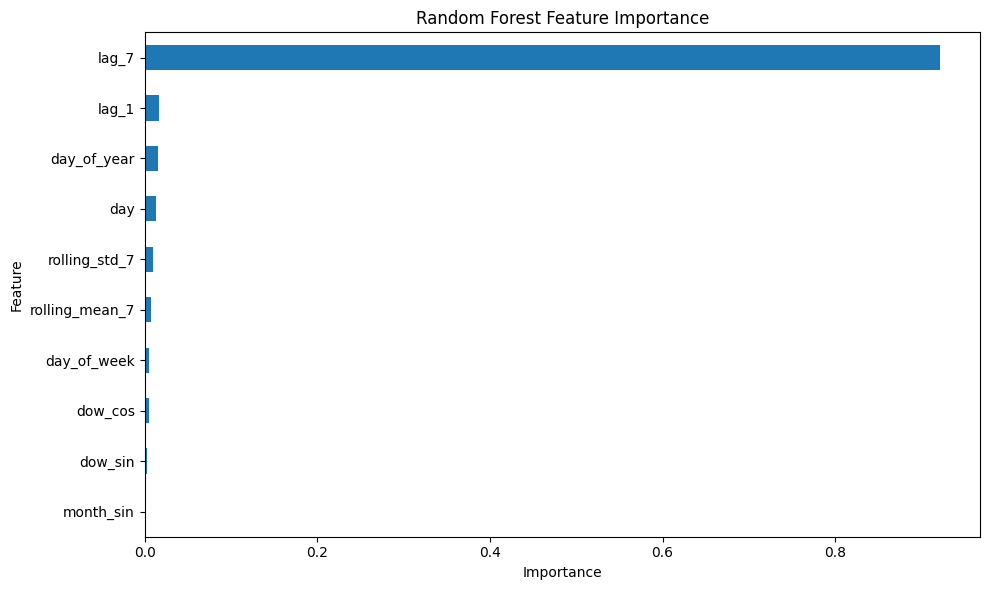

In [95]:
plt.figure(figsize=(10, 6))

importance.head(10).sort_values().plot(
    kind="barh"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## 99. Comparing Classical and ML Models

In [96]:
model_comparison = pd.DataFrame(
    {
        "Model": [
            "Naive",
            "Seasonal Naive",
            "Drift",
            "Linear Regression",
            "Random Forest"
        ],
        "MAE": [
            mean_absolute_error(test, naive_forecast),
            mean_absolute_error(test, seasonal_naive_forecast),
            mean_absolute_error(test, drift_forecast),
            linear_mae,
            rf_mae
        ],
        "RMSE": [
            np.sqrt(
                mean_squared_error(
                    test,
                    naive_forecast
                )
            ),
            np.sqrt(
                mean_squared_error(
                    test,
                    seasonal_naive_forecast
                )
            ),
            np.sqrt(
                mean_squared_error(
                    test,
                    drift_forecast
                )
            ),
            linear_rmse,
            rf_rmse
        ]
    }
)

model_comparison.sort_values(
    "RMSE"
)

,Model,MAE,RMSE
0,Naive,1.124549,1.356256
2,Drift,1.263909,1.548591
1,Seasonal Naive,1.338448,1.652452
3,Linear Regression,1.905334,2.344592
4,Random Forest,3.689924,4.641261


# 100. Classical Models vs Machine Learning

There is no universal winner.

### Classical Models

Examples:

$$
ARIMA
$$

$$
SARIMA
$$

$$
Holt-Winters
$$

Strengths:

- Strong statistical foundation
- Interpretable
- Effective for structured temporal patterns
- Good for smaller datasets
- Natural forecasting framework

---

### Machine Learning

Examples:

$$
Random\ Forest
$$

$$
XGBoost
$$

$$
LightGBM
$$

Strengths:

- Nonlinear relationships
- Many predictors
- Feature interactions
- External variables
- Flexible feature engineering

The correct choice depends on:

$$
\boxed{
\text{Data}
+
\text{Forecast Horizon}
+
\text{Seasonality}
+
\text{External Variables}
+
\text{Validation Performance}
}
$$

# 101. Recursive Multi-Step Forecasting

Suppose we want to predict several future observations.

A recursive strategy predicts one step at a time.

First:

$$
\hat{Y}_{t+1}
$$

Then the prediction becomes an input:

$$
\hat{Y}_{t+2}
=
f(
\hat{Y}_{t+1},
Y_t,
\ldots
)
$$

Then:

$$
\hat{Y}_{t+3}
=
f(
\hat{Y}_{t+2},
\hat{Y}_{t+1},
\ldots
)
$$

### Advantage

Only one model is required.

### Disadvantage

Forecast errors can accumulate:

$$
\text{Error}_{t+1}
\rightarrow
\text{Input Error}_{t+2}
\rightarrow
\text{Larger Error}_{t+3}
$$

This is called **error propagation**.

# 102. Direct Multi-Step Forecasting

Instead of recursively predicting each future value, we can train separate models for different forecast horizons.

For example:

$$
Model_1 \rightarrow Y_{t+1}
$$

$$
Model_2 \rightarrow Y_{t+2}
$$

$$
Model_3 \rightarrow Y_{t+3}
$$

and so on.

### Advantage

Errors do not recursively propagate through previous predictions.

### Disadvantage

Multiple models must be trained.

Therefore:

| Strategy | Advantage | Disadvantage |
|---|---|---|
| Recursive | One model | Error propagation |
| Direct | Less error propagation | Multiple models |

# 103. Forecast Horizon

The forecast horizon is the number of future observations we want to predict.

Examples:

$$
h=1
$$

One-step forecast.

$$
h=7
$$

Seven-step forecast.

$$
h=30
$$

Thirty-step forecast.

Model performance often changes with the horizon.

A model that performs extremely well for:

$$
h=1
$$

may perform poorly for:

$$
h=30
$$

Therefore, the forecast horizon must be defined before evaluating a forecasting system.

# 104. Practical Time-Series Validation Workflow

A robust forecasting workflow is:

```text
Raw Data
   ↓
Chronological Ordering
   ↓
Exploratory Analysis
   ↓
Feature Engineering
   ↓
Train / Validation / Test
   ↓
Baseline
   ↓
Candidate Models
   ↓
Walk-Forward Validation
   ↓
Hyperparameter Selection
   ↓
Final Training
   ↓
Test Evaluation
   ↓
Residual Diagnostics
   ↓
Future Forecast

# 106. Multivariate Time Series

A univariate time series contains one variable:

$$
Y_t
$$

A multivariate time series contains multiple variables:

$$
\mathbf{Y}_t =
\begin{bmatrix}
Y_{1,t}\\
Y_{2,t}\\
\vdots\\
Y_{k,t}
\end{bmatrix}
$$

For example, an energy forecasting problem might contain:

$$
\mathbf{Y}_t =
\begin{bmatrix}
Demand_t\\
Temperature_t\\
Humidity_t\\
Price_t
\end{bmatrix}
$$

The variables may influence each other over time.

Examples:

- Temperature → electricity demand
- Advertising → sales
- Interest rates → economic indicators
- Traffic → website requests

Multivariate time-series models attempt to exploit these relationships.

# 107. Cross-Correlation

Autocorrelation measures the relationship between a series and its own past.

Cross-correlation examines relationships between two different series.

For two series:

$$
X_t
$$

and:

$$
Y_t
$$

we may investigate whether:

$$
X_{t-k}
$$

is related to:

$$
Y_t
$$

for different values of $k$.

This can help identify potential lagged relationships.

However:

> Correlation does not imply causation.

Cross-correlation should therefore be interpreted carefully, especially when both series contain trends or seasonality.

# 108. Vector Autoregression (VAR)

VAR extends autoregressive models to multiple time series.

For a two-variable system:

$$
\mathbf{Y}_t =
\begin{bmatrix}
Y_{1,t}\\
Y_{2,t}
\end{bmatrix}
$$

A VAR($p$) model can be written as:

$$
\mathbf{Y}_t
=
\mathbf{c}
+
A_1\mathbf{Y}_{t-1}
+
A_2\mathbf{Y}_{t-2}
+
\cdots
+
A_p\mathbf{Y}_{t-p}
+
\boldsymbol{\epsilon}_t
$$

where:

- $\mathbf{Y}_t$ = vector of variables
- $\mathbf{c}$ = intercept vector
- $A_i$ = coefficient matrices
- $p$ = lag order
- $\boldsymbol{\epsilon}_t$ = vector of errors

Unlike a univariate AR model, VAR allows each variable to depend on the past values of **all variables**.

# 109. VAR Intuition

Suppose we model:

$$
Demand_t
$$

and:

$$
Temperature_t
$$

A VAR model could contain:

$$
Demand_t =
f(
Demand_{t-1},
Temperature_{t-1},
Demand_{t-2},
Temperature_{t-2}
)
$$

and simultaneously:

$$
Temperature_t =
f(
Temperature_{t-1},
Demand_{t-1},
Temperature_{t-2},
Demand_{t-2}
)
$$

Thus:

$$
\boxed{
\text{Each variable can depend on the history of every variable}
}
$$

VAR is useful when multiple time series interact dynamically.

## 110. Preparing a VAR Dataset

In [97]:
var_df = pd.DataFrame(
    {
        "demand": df["value"],
        "temperature": (
            25
            + 5 * np.sin(
                2 * np.pi *
                np.arange(len(df)) / 365
            )
            + np.random.normal(
                0,
                0.5,
                len(df)
            )
        )
    },
    index=df.index
)

var_df.head()

,demand,temperature
date,,
2025-01-01,51.490142,24.585502
2025-01-02,57.540885,24.805976
2025-01-03,61.967070,25.545755
2025-01-04,59.320015,25.563283
2025-01-05,45.508153,25.333561


## 111. VAR Model

In [98]:
from statsmodels.tsa.api import VAR

var_train = var_df.iloc[:-30]

var_model = VAR(
    var_train
)

var_result = var_model.fit(
    maxlags=7,
    ic="aic"
)

print(var_result.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Fri, 11, Sep, 2026
Time:                     02:27:54
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                    1.70780
Nobs:                     328.000    HQIC:                   1.49929
Log likelihood:          -1124.01    FPE:                    3.90011
AIC:                      1.36088    Det(Omega_mle):         3.56645
--------------------------------------------------------------------
Results for equation demand
                    coefficient       std. error           t-stat            prob
---------------------------------------------------------------------------------
const                  1.331525         4.162187            0.320           0.749
L1.demand              0.235482         0.051416            4.580           0.000
L1.temperature         0.314090         0.350919       

c:\Users\soumy\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


# 111. Selecting the VAR Lag Order

The lag order determines how much historical information is used.

Possible information criteria include:

- AIC
- BIC
- HQIC
- FPE

For example:

$$
VAR(1)
$$

uses one previous time step.

While:

$$
VAR(7)
$$

uses seven previous time steps.

A reasonable workflow is:

$$
\text{Candidate Lags}
\rightarrow
\text{Information Criterion}
\rightarrow
\text{Validation}
$$

Do not select the lag order solely because a larger value gives a better training fit.

## 112. VAR Forecast

In [99]:
lag_order = var_result.k_ar

var_input = var_train.values[-lag_order:]

var_forecast = var_result.forecast(
    y=var_input,
    steps=30
)

var_forecast_df = pd.DataFrame(
    var_forecast,
    columns=var_df.columns
)

var_forecast_df.head()

,demand,temperature
0,90.634428,22.021769
1,97.933137,21.877524
2,103.994929,21.942403
3,103.348774,21.867956
4,98.902689,21.714600


# 113. Granger Causality

Granger causality asks whether past values of one variable provide useful information for predicting another variable.

Suppose:

$$
X_t
$$

and:

$$
Y_t
$$

We compare models with and without past values of $X$.

If including:

$$
X_{t-1},X_{t-2},\ldots
$$

significantly improves prediction of $Y_t$, then $X$ is said to **Granger-cause** $Y$.

### Important

Granger causality does not establish philosophical or true causal relationships.

It means:

> Past values of $X$ contain predictive information about $Y$ beyond the information contained in the past of $Y$ itself.

Therefore:

$$
\boxed{
\text{Granger causality}
\neq
\text{true causation}
}
$$

## 114. Granger Causality Test

In [101]:
from statsmodels.tsa.stattools import grangercausalitytests

test_data = var_df[
    ["demand", "temperature"]
].dropna()

granger_result = grangercausalitytests(
    test_data,
    maxlag=3
)

print("Granger Causality Test")
print("-" * 35)

for lag, result in granger_result.items():
    p_value = result[0]["ssr_ftest"][1]

    print(
        f"Lag {lag}: "
        f"F-statistic = {result[0]['ssr_ftest'][0]:.4f}, "
        f"p-value = {p_value:.4f}"
    )

Granger Causality Test
-----------------------------------
Lag 1: F-statistic = 16.2595, p-value = 0.0001
Lag 2: F-statistic = 20.6307, p-value = 0.0000
Lag 3: F-statistic = 11.1271, p-value = 0.0000


# 115. Structural Breaks

A structural break occurs when the underlying data-generating process changes.

For example:

```text
Before Break          After Break

Mean = 100             Mean = 150
Variance = 10          Variance = 20
Trend = positive       Trend = negative



Possible causes include:

Economic crises
Policy changes
New technology
Market regime changes
Pandemics
Product launches
Changes in customer behavior

A model trained entirely on pre-break data may perform poorly after the break.

Therefore, we should consider whether:

$$ P(Y_t) $$

or the relationship:

$$ P(Y_t|Y_{t-1},\ldots) $$

has changed over time.



# 116. Detecting Structural Changes Visually


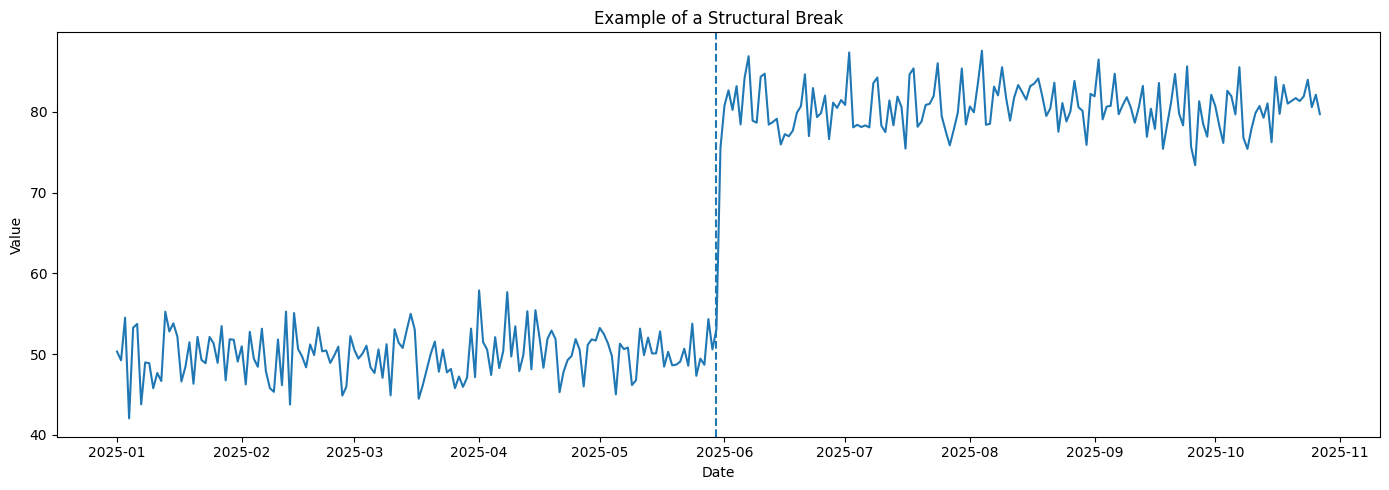

In [103]:
break_series = pd.Series(
    np.concatenate(
        [
            np.random.normal(50, 3, 150),
            np.random.normal(80, 3, 150)
        ]
    ),
    index=pd.date_range(
        "2025-01-01",
        periods=300,
        freq="D"
    )
)

plt.figure(figsize=(14, 5))

plt.plot(
    break_series
)

plt.axvline(
    break_series.index[149],
    linestyle="--"
)

plt.title("Example of a Structural Break")
plt.xlabel("Date")
plt.ylabel("Value")

plt.tight_layout()
plt.show()

# 117. Handling Structural Breaks

Possible approaches include:

### 1. Retraining

Train the model using more recent data.

### 2. Rolling Windows

Discard older observations.

### 3. Regime-Specific Models

Use different models for different regimes.

### 4. Break Indicators

Add a feature representing the structural change.

### 5. Change-Point Detection

Use statistical methods to identify potential break points.

The correct strategy depends heavily on the application.

A structural break is not simply "noise".

It can indicate that the underlying process itself has changed.

# 118. Outliers in Time Series

An outlier is an observation that is unusually different from the surrounding observations.

Examples:

- Sensor failure
- Data-entry error
- Extreme weather
- Market shock
- Unexpected demand spike

Outliers should not automatically be removed.

First determine whether the observation is:

$$
\boxed{
\text{Error}
\quad\text{or}\quad
\text{Real Event}
}
$$

Removing a genuine extreme event can make a forecasting model less realistic.

## 119. Detecting Outliers

In [104]:
q1 = df["value"].quantile(0.25)
q3 = df["value"].quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = df[
    (df["value"] < lower_bound) |
    (df["value"] > upper_bound)
]

print("Number of potential outliers:", len(outliers))

Number of potential outliers: 0


# 120. Missing Time Points

Missing values and missing timestamps are different problems.

### Missing Value

The timestamp exists, but the measurement is missing.

```text
10:00 → 100
11:00 → NaN
12:00 → 105

### Missing Timestamp

The timestamp itself is absent.
```text
10:00 → 100
12:00 → 105

The 11:00 observation does not exist in the dataset.

This distinction matters because many time-series models assume a regular sampling frequency.

# 121. Detecting Missing Timestamps

In [105]:
expected_index = pd.date_range(
    start=df.index.min(),
    end=df.index.max(),
    freq="D"
)

missing_timestamps = expected_index.difference(
    df.index
)

print(
    "Missing timestamps:",
    len(missing_timestamps)
)

Missing timestamps: 0


# 122. Handling Missing Values

Possible approaches include:

### Forward Fill

$$
Y_t=Y_{t-1}
$$

Useful in some state-like measurements.

### Backward Fill

$$
Y_t=Y_{t+1}
$$

### Interpolation

Estimate the missing value using neighboring observations.

### Model-Based Imputation

Use a statistical or machine-learning model.

The correct choice depends on:

- Variable meaning
- Missingness mechanism
- Frequency
- Forecasting objective

Do not blindly fill every missing value with the mean.

# 123. Additional Forecast Metrics

### Mean Absolute Percentage Error

$$
MAPE =
\frac{100}{n}
\sum_{t=1}^{n}
\left|
\frac{Y_t-\hat{Y}_t}{Y_t}
\right|
$$

MAPE can become problematic when:

$$
Y_t \approx 0
$$

or:

$$
Y_t=0
$$

---

### Symmetric Mean Absolute Percentage Error

A common form is:

$$
sMAPE =
\frac{100}{n}
\sum_{t=1}^{n}
\frac{
|Y_t-\hat{Y}_t|
}{
(|Y_t|+|\hat{Y}_t|)/2
}
$$

sMAPE can reduce some problems associated with MAPE, but it is not perfect either.

For many applications, MAE and RMSE are strong starting metrics.

# 124. End-to-End Time-Series Forecasting Project

We will now combine the major concepts from this notebook.

### Objective

Build and compare forecasting models for a time series.

### Workflow

```text
Load Data
    ↓
Inspect Data
    ↓
Datetime Conversion
    ↓
Check Frequency
    ↓
Visualize
    ↓
Trend / Seasonality
    ↓
Missing Values
    ↓
Outliers
    ↓
Stationarity
    ↓
ADF / KPSS
    ↓
Differencing if Required
    ↓
ACF / PACF
    ↓
Baseline Models
    ↓
ARIMA / SARIMA
    ↓
Feature Engineering
    ↓
Machine Learning
    ↓
Walk-Forward Validation
    ↓
Residual Diagnostics
    ↓
Model Comparison
    ↓
Final Forecast


---

# 125. Creating a Realistic Forecasting Dataset

For this final project, we will create a synthetic demand dataset containing:

- Trend
- Weekly seasonality
- Annual-like smooth variation
- Random noise

The advantage of a controlled dataset is that we know the underlying structure and can test whether our models recover it.

In [106]:
np.random.seed(42)

n = 730

dates = pd.date_range(
    start="2024-01-01",
    periods=n,
    freq="D"
)

trend = np.linspace(
    100,
    160,
    n
)

weekly = (
    15 *
    np.sin(
        2 * np.pi *
        np.arange(n) / 7
    )
)

yearly = (
    10 *
    np.sin(
        2 * np.pi *
        np.arange(n) / 365
    )
)

noise = np.random.normal(
    0,
    5,
    n
)

demand = (
    trend
    + weekly
    + yearly
    + noise
)

project_df = pd.DataFrame(
    {
        "demand": demand
    },
    index=dates
)

project_df.head()

,demand
2024-01-01,102.483571
2024-01-02,111.290589
2024-01-03,118.371187
2024-01-04,114.886516
2024-01-05,93.338219


## 126. Project Visualization

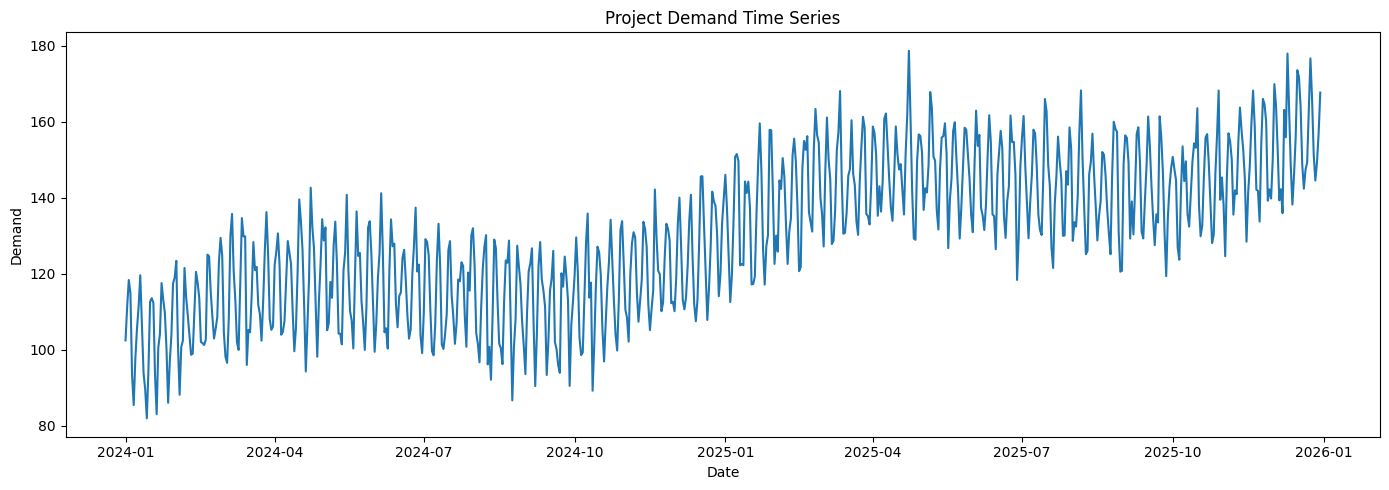

In [107]:
plt.figure(figsize=(14, 5))

plt.plot(
    project_df["demand"]
)

plt.title("Project Demand Time Series")
plt.xlabel("Date")
plt.ylabel("Demand")

plt.tight_layout()
plt.show()

# 127. Train / Validation / Test Split

We will divide the data chronologically.

```text
Past                         Future
███████████████ | █████ | ░░░░░░░
     Train       Validation   Test

The validation set is used for model selection.

The final test set is kept separate until the end.

This prevents us from repeatedly tuning the model against the test set.

In [108]:
n_total = len(project_df)

train_end = int(
    n_total * 0.70
)

validation_end = int(
    n_total * 0.85
)

project_train = project_df.iloc[:train_end]
project_validation = project_df.iloc[
    train_end:validation_end
]
project_test = project_df.iloc[
    validation_end:
]

print("Train:", len(project_train))
print("Validation:", len(project_validation))
print("Test:", len(project_test))

Train: 510
Validation: 110
Test: 110


## 128. Baseline

In [109]:
baseline_prediction = pd.Series(
    project_train["demand"].iloc[-1],
    index=project_validation.index
)

baseline_mae = mean_absolute_error(
    project_validation["demand"],
    baseline_prediction
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        project_validation["demand"],
        baseline_prediction
    )
)

print(f"Baseline MAE:  {baseline_mae:.4f}")
print(f"Baseline RMSE: {baseline_rmse:.4f}")

Baseline MAE:  15.6930
Baseline RMSE: 18.8229


## 129. Feature Engineering

In [110]:
project_ml = project_df.copy()

project_ml["lag_1"] = (
    project_ml["demand"]
    .shift(1)
)

project_ml["lag_7"] = (
    project_ml["demand"]
    .shift(7)
)

project_ml["lag_14"] = (
    project_ml["demand"]
    .shift(14)
)

project_ml["rolling_mean_7"] = (
    project_ml["demand"]
    .shift(1)
    .rolling(7)
    .mean()
)

project_ml["rolling_std_7"] = (
    project_ml["demand"]
    .shift(1)
    .rolling(7)
    .std()
)

project_ml["day_of_week"] = (
    project_ml.index.dayofweek
)

project_ml["month"] = (
    project_ml.index.month
)

project_ml["dow_sin"] = np.sin(
    2 * np.pi *
    project_ml["day_of_week"] / 7
)

project_ml["dow_cos"] = np.cos(
    2 * np.pi *
    project_ml["day_of_week"] / 7
)

project_ml = project_ml.dropna()

project_ml.head()

,demand,lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7,day_of_week,month,dow_sin,dow_cos
2024-01-15,94.914402,81.995301,105.615386,102.483571,101.277858,13.222159,0,1,0.000000,1.000000
2024-01-16,112.704135,94.914402,111.411324,111.290589,99.749146,13.255651,1,1,0.781831,0.623490
2024-01-17,113.596217,112.704135,119.620548,118.371187,99.933833,13.452759,2,1,0.974928,-0.222521
2024-01-18,112.363494,113.596217,106.727144,114.886516,99.073215,12.109016,3,1,0.433884,-0.900969
2024-01-19,93.482317,112.363494,93.950712,93.338219,99.878408,12.866495,4,1,-0.433884,-0.900969


## 130. Final ML Split

In [111]:
train_ml = project_ml[
    project_ml.index < project_validation.index[0]
]

validation_ml = project_ml[
    (project_ml.index >= project_validation.index[0])
    &
    (project_ml.index < project_test.index[0])
]

test_ml = project_ml[
    project_ml.index >= project_test.index[0]
]

features = [
    "lag_1",
    "lag_7",
    "lag_14",
    "rolling_mean_7",
    "rolling_std_7",
    "day_of_week",
    "month",
    "dow_sin",
    "dow_cos"
]

X_train = train_ml[features]
y_train = train_ml["demand"]

X_validation = validation_ml[features]
y_validation = validation_ml["demand"]

X_test = test_ml[features]
y_test = test_ml["demand"]

## 131. Final Random Forest

In [112]:
final_rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

final_rf.fit(
    X_train,
    y_train
)

validation_pred = final_rf.predict(
    X_validation
)

validation_mae = mean_absolute_error(
    y_validation,
    validation_pred
)

validation_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        validation_pred
    )
)

print(
    f"Validation MAE: {validation_mae:.4f}"
)

print(
    f"Validation RMSE: {validation_rmse:.4f}"
)

Validation MAE: 4.9189
Validation RMSE: 6.3391


## 132. Final Test Evaluation

In [113]:
test_pred = final_rf.predict(
    X_test
)

test_mae = mean_absolute_error(
    y_test,
    test_pred
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        test_pred
    )
)

print(f"Test MAE:  {test_mae:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")

Test MAE:  5.8614
Test RMSE: 7.2975


## 133. Actual vs Forecast

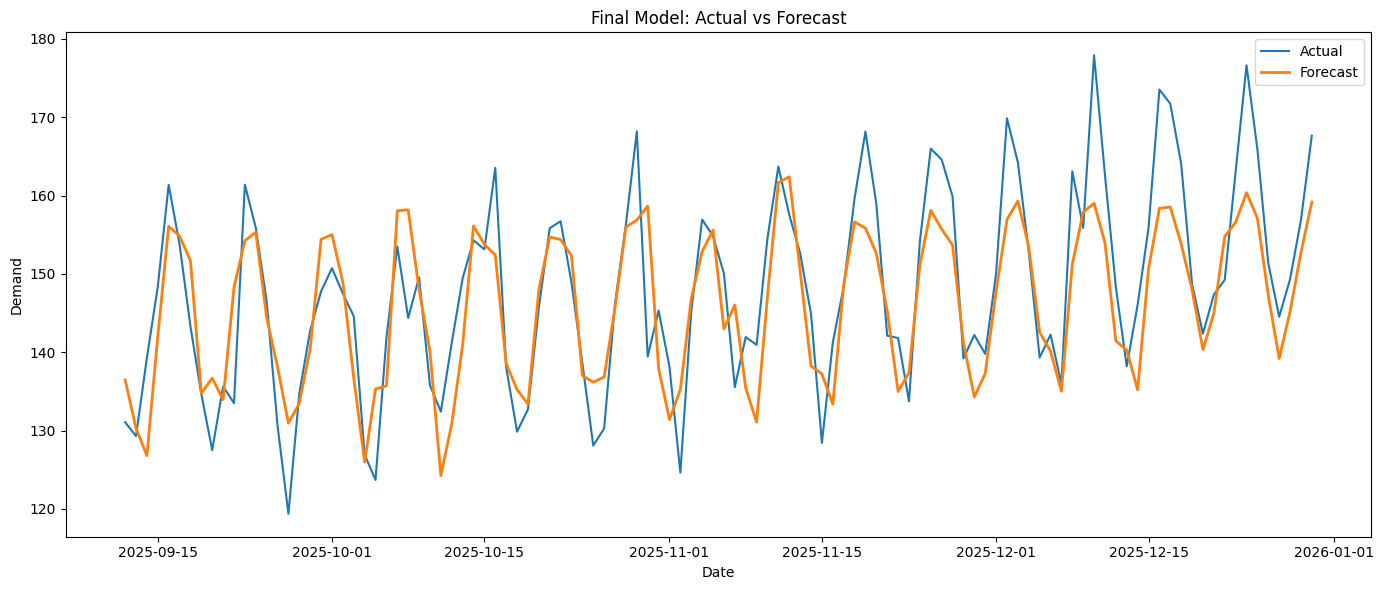

In [114]:
plt.figure(figsize=(14, 6))

plt.plot(
    y_test.index,
    y_test,
    label="Actual"
)

plt.plot(
    y_test.index,
    test_pred,
    label="Forecast",
    linewidth=2
)

plt.title("Final Model: Actual vs Forecast")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.legend()

plt.tight_layout()
plt.show()

## 134. Final Residual Analysis

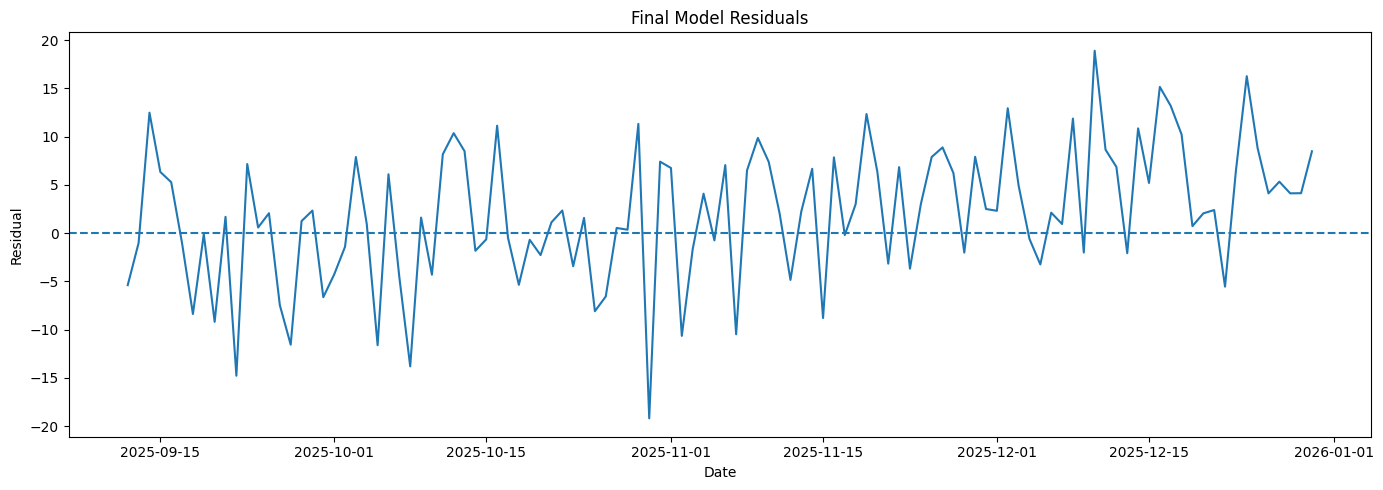

In [115]:
final_residuals = (
    y_test - test_pred
)

plt.figure(figsize=(14, 5))

plt.plot(
    final_residuals
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("Final Model Residuals")
plt.xlabel("Date")
plt.ylabel("Residual")

plt.tight_layout()
plt.show()

<Figure size 1200x500 with 0 Axes>

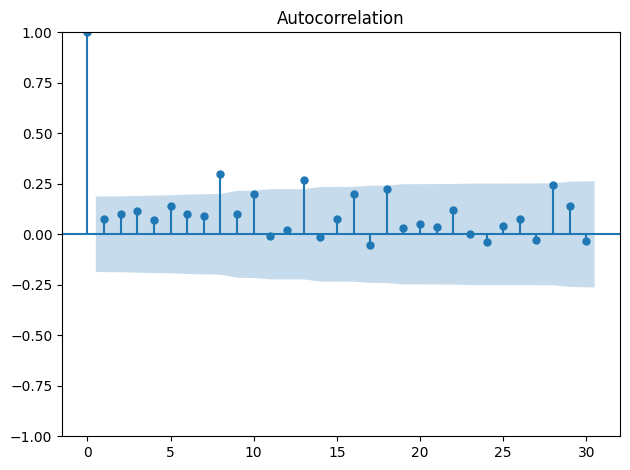

In [116]:
plt.figure(figsize=(12, 5))

plot_acf(
    final_residuals,
    lags=30
)

plt.tight_layout()
plt.show()

## 135. Final Model Comparison

In [117]:
final_comparison = pd.DataFrame(
    {
        "Model": [
            "Naive Baseline",
            "Random Forest"
        ],
        "MAE": [
            baseline_mae,
            test_mae
        ],
        "RMSE": [
            baseline_rmse,
            test_rmse
        ]
    }
)

final_comparison.sort_values(
    "RMSE"
)

,Model,MAE,RMSE
1,Random Forest,5.861418,7.297459
0,Naive Baseline,15.692996,18.822888


# 136. Final Time-Series Forecasting Checklist

Before deploying a forecasting model, verify:

### Data

- [ ] Datetime column correctly parsed
- [ ] Data sorted chronologically
- [ ] Frequency understood
- [ ] Missing timestamps checked
- [ ] Missing values handled
- [ ] Outliers investigated

### Exploration

- [ ] Trend examined
- [ ] Seasonality examined
- [ ] Rolling statistics examined
- [ ] ACF examined
- [ ] PACF examined

### Statistical Modeling

- [ ] Stationarity checked
- [ ] ADF/KPSS considered
- [ ] Differencing considered
- [ ] ARIMA/SARIMA candidates evaluated
- [ ] Residuals checked

### Machine Learning

- [ ] Lag features created
- [ ] Rolling features shifted correctly
- [ ] Calendar features created
- [ ] No future information used
- [ ] Chronological splitting used

### Evaluation

- [ ] Baseline established
- [ ] Validation set separated
- [ ] Test set kept untouched
- [ ] Walk-forward validation considered
- [ ] MAE/RMSE evaluated
- [ ] Forecast horizon considered

### Final Model

- [ ] Model beats a reasonable baseline
- [ ] Residuals have little remaining structure
- [ ] Forecast uncertainty considered
- [ ] Model assumptions understood
- [ ] Production data availability matches training assumptions

# 137. Time Series — Final Summary

Time-series analysis combines statistical modeling, machine learning, and careful validation.

The fundamental concepts are:

$$
\boxed{
\text{Trend}
+
\text{Seasonality}
+
\text{Autocorrelation}
+
\text{Noise}
}
$$

Stationarity provides the foundation for many classical models.

$$
\text{Non-Stationary}
\rightarrow
\text{Differencing}
\rightarrow
\text{Stationary}
$$

Autocorrelation helps us understand temporal dependence.

$$
ACF
\rightarrow
\text{Overall Lag Relationships}
$$

$$
PACF
\rightarrow
\text{Direct Lag Relationships}
$$

Classical models include:

$$
AR
\rightarrow
MA
\rightarrow
ARMA
\rightarrow
ARIMA
\rightarrow
SARIMA
$$

Exponential smoothing provides another family of forecasting methods:

$$
SES
\rightarrow
Holt
\rightarrow
Holt-Winters
$$

Machine learning approaches transform temporal structure into features:

$$
\text{Lags}
+
\text{Rolling Statistics}
+
\text{Calendar Features}
\rightarrow
ML Model
$$

Finally:

$$
\boxed{
\text{Time-Aware Validation}
+
\text{Strong Baseline}
+
\text{Residual Diagnostics}
+
\text{Out-of-Sample Evaluation}
}
$$

are essential for reliable forecasting.

# 138. Final Takeaway

The most important lesson from time-series machine learning is not a particular algorithm.

It is the discipline of respecting time.

$$
\boxed{
\text{Past}
\rightarrow
\text{Model}
\rightarrow
\text{Future}
}
$$

A strong forecasting workflow therefore follows:

```text
Understand the data
        ↓
Understand temporal structure
        ↓
Check stationarity
        ↓
Build a simple baseline
        ↓
Build statistical models
        ↓
Engineer temporal features
        ↓
Build ML models
        ↓
Validate chronologically
        ↓
Check residuals
        ↓
Compare against baseline
        ↓
Forecast the future


---

## ✅ `04_Time_Series.ipynb` is now essentially complete

Our notebook now spans:

```text
01  Time Series Fundamentals
02  Components
03  Datetime Handling
04  Resampling
05  Rolling / Expanding Windows
06  Lag Features
07  Stationarity
08  ADF
09  KPSS
10  Differencing
11  ACF
12  PACF
13  White Noise
14  Ljung-Box
15  AR
16  MA
17  ARMA
18  ARIMA
19  Seasonal Differencing
20  Decomposition
21  STL
22  SARIMA
23  SARIMAX
24  Forecast Baselines
25  Exponential Smoothing
26  Holt
27  Holt-Winters
28  Prediction Intervals
29  Time-Series Validation
30  Walk-Forward Validation
31  Expanding Windows
32  Rolling Windows
33  Data Leakage
34  Calendar Features
35  Cyclical Encoding
36  ML Forecasting
37  Random Forest
38  Gradient Boosting
39  Recursive Forecasting
40  Direct Forecasting
41  Multivariate Time Series
42  VAR
43  Granger Causality
44  Structural Breaks
45  Outliers
46  Missing Timestamps
47  Forecast Metrics
48  End-to-End Forecasting Project
49  Model Comparison
50  Final Forecasting Checklist